Example of how to parse the files and load data in dataframes.

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('TkAgg')
%matplotlib notebook
%matplotlib inline


In [12]:
data_path = os.getcwd() + os.sep + 'data'
print(data_path)

/Users/filipnordqvist/Documents/GitHub/Examensarbete/data


In [13]:
# Loading data functions
def loader(data_path, blacklist):
    data = []
    all_data_csv = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
    for name in os.listdir(data_path):
        if name != '.DS_Store' and 'csv' not in name and 'txt' not in name:
            print('---------------------------------------------')
            print("Loading walking data for subject: ",name)
            new_path = data_path + os.sep + name
            for name_in in os.listdir(new_path):
                if name_in != '.DS_Store' and name_in not in blacklist:
                    print("Loading test: ", name_in)
                    motion_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'motion.csv')
                    position_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'positions.csv')
                    orientation_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'orientation.csv')
                    steps_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'steps.csv')
                    event_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'events.csv')

                    anon_test = walking_test(
                        name_in, event_csv,
                        motion_csv,
                        orientation_csv,
                        position_csv,
                        steps_csv
                    )
                    data.append(anon_test)

    return data, all_data_csv

class walking_test:
    def __init__(self, filename, events, motion, orientation, positions, steps): #
        self.filename = filename
        self.events = events
        self.motion = motion
        self.orientation = orientation
        self.positions = positions
        self.steps = steps

In [14]:
# Uploading metadata and determining blacklist
metadata = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
print("Metadata columns: ", metadata.columns)
noIMU = metadata[metadata['hasMotion'] == False]['testName'].tolist()
noGPS = metadata[metadata['hasGNSS'] == False]['testName'].tolist()
blacklist = noIMU + noGPS
print("Blacklist: ", blacklist)

Metadata columns:  Index(['subject', 'testID', 'testName', 'isPatient', 'distanceReference',
       'hasMotion', 'hasGNSS', 'device', 'distanceByApp', 'totSteps',
       'path curvature', 'total_gaps_time_inertial', 'total_gaps_time_gnss',
       'gt_type', 'country', 'gnss_anonimized', 'duration [s]', 'fs_acc',
       'fs_gnss', 'fs_steps', 'average_walking_speed', 'smartphone_position',
       'smartphone app'],
      dtype='object')
Blacklist:  ['0_0', '0_1', '0_2', '0_3', '0_4', '0_5', '0_6', '0_7', '0_8', '0_9', '0_10', '0_11', '0_12', '0_13', '0_14', '1_0', '1_1', '1_2', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '2_0', '2_1', '2_2', '2_3', '2_4', '2_5', '2_6', '2_7', '2_8', '2_9', '3_0', '3_5', '3_6', '3_7', '3_8', '3_9', '9_0', '9_1', '9_2', '9_3', '9_4', '9_5', '9_6', '9_7', '9_8', '9_9', '9_10', '15_0', '15_1', '15_2', '15_3', '15_4']


In [15]:
# Loading data
selection, info_all_tests = loader(data_path, blacklist=blacklist)
print("Successfully loaded data")

---------------------------------------------
Loading walking data for subject:  subject_12
Loading test:  12_5
Loading test:  12_2
Loading test:  12_3
Loading test:  12_4
Loading test:  12_10
Loading test:  12_11
Loading test:  12_1
Loading test:  12_6
Loading test:  12_8
Loading test:  12_9
Loading test:  12_7
Loading test:  12_0
Loading test:  12_13
Loading test:  12_12
---------------------------------------------
Loading walking data for subject:  subject_15
---------------------------------------------
Loading walking data for subject:  subject_14
Loading test:  14_9
Loading test:  14_0
Loading test:  14_7
Loading test:  14_6
Loading test:  14_1
Loading test:  14_8
Loading test:  14_14
Loading test:  14_13
Loading test:  14_12
Loading test:  14_4
Loading test:  14_3
Loading test:  14_2
Loading test:  14_5
Loading test:  14_10
Loading test:  14_11
---------------------------------------------
Loading walking data for subject:  subject_13
Loading test:  13_11
Loading test:  13_10
L

In [16]:
# Example of what a walking test contains:
print("Selection[0] contains: ")
print("Filename: ", selection[0].filename)
print("Events: ", selection[0].events.head())
print("Motion: ", selection[0].motion.head())
print("Orientation: ", selection[0].orientation.head())
print("Positions: ", selection[0].positions.head())
print("Steps: ", selection[0].steps.head())

Selection[0] contains: 
Filename:  12_5
Events:     Unnamed: 0  signalStart  testStart        testEnd
0           0            0      961.0  241776.000023
Motion:     Unnamed: 0     ms    accelX    accelY    accelZ  accelWithGX  accelWithGY  \
0           0  301.0  0.438315 -0.063984 -0.070899    -0.022308     1.661179   
1           1  326.0  0.498090 -0.201496  0.016141    -0.035461     1.648026   
2           2  344.0  0.458053 -0.219058 -0.166888    -0.171860     1.747330   
3           3  366.0  0.212662 -0.051397 -0.305197    -0.256805     1.845428   
4           4  383.0  0.212662 -0.051397 -0.305197    -0.429092     1.931564   

   accelWithGZ  rotRateAlpha  rotRateBeta  rotRateGamma  interval  
0     9.639145      2.197900     3.448972      7.877995        16  
1     9.442932      5.656489     1.173263      5.241214        16  
2     9.349625      6.130341     0.611111      3.747971        16  
3     9.267059      7.771335     2.842233      4.861783        16  
4     9.143829 

Total distance traveled for 12_5: 261.31 meters


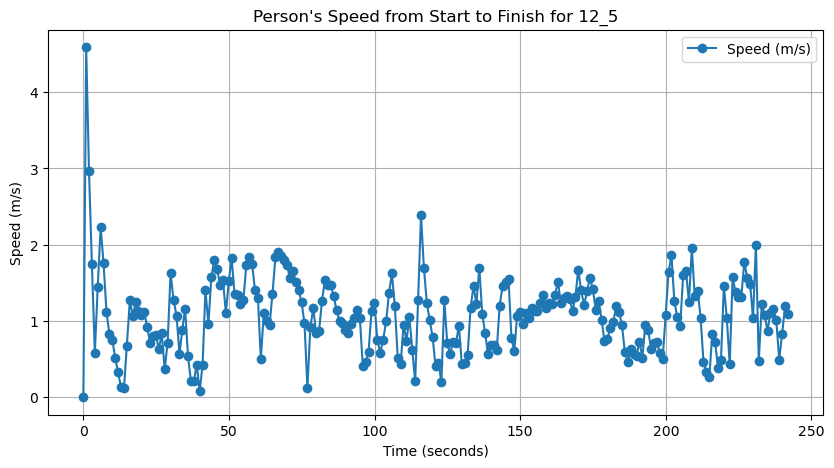

Total distance traveled for 12_2: 536.30 meters


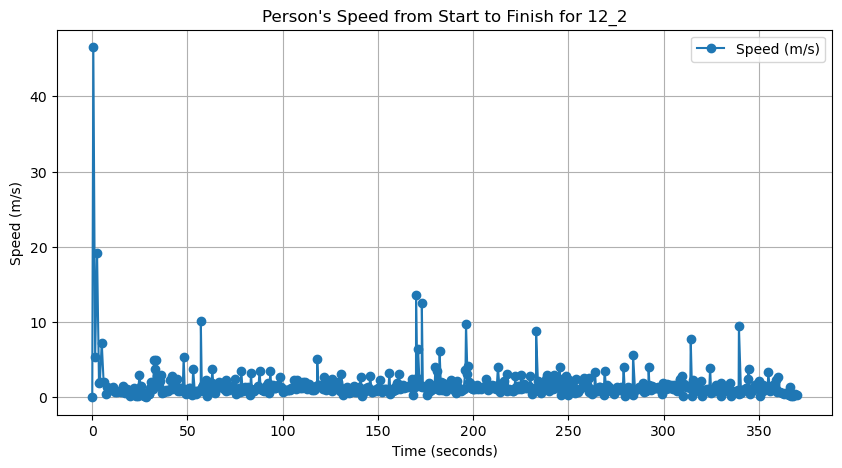

Total distance traveled for 12_3: 465.94 meters


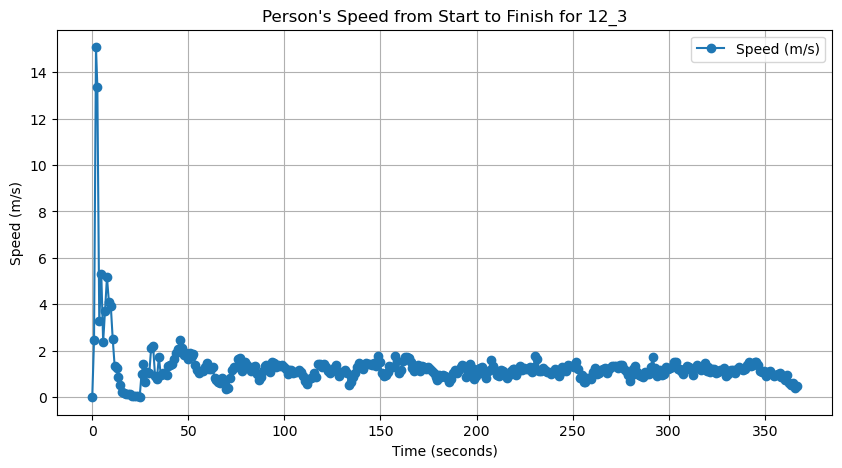

Total distance traveled for 12_4: 331.33 meters


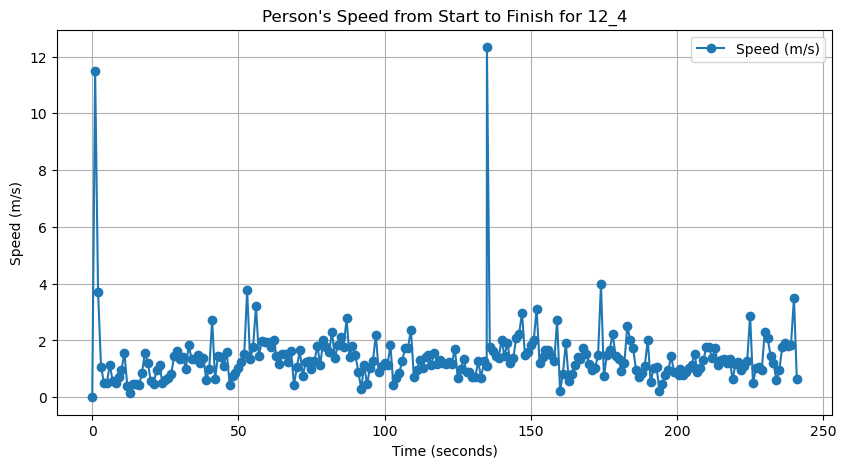

Total distance traveled for 12_10: 350.25 meters


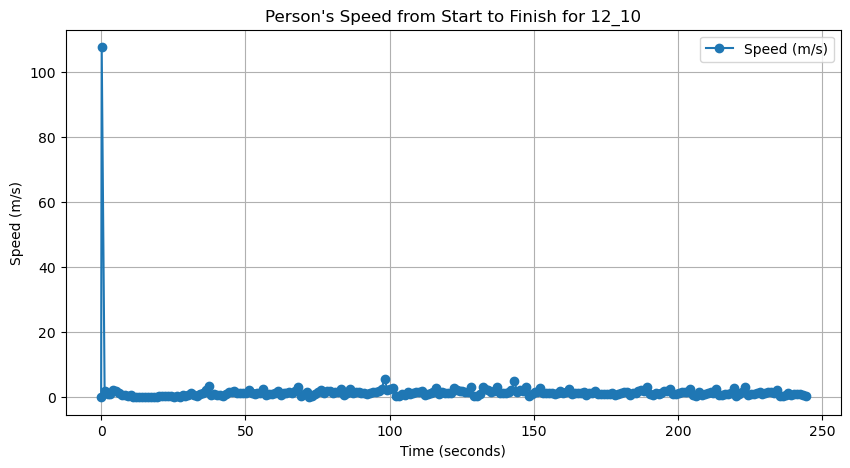

Total distance traveled for 12_11: 267.03 meters


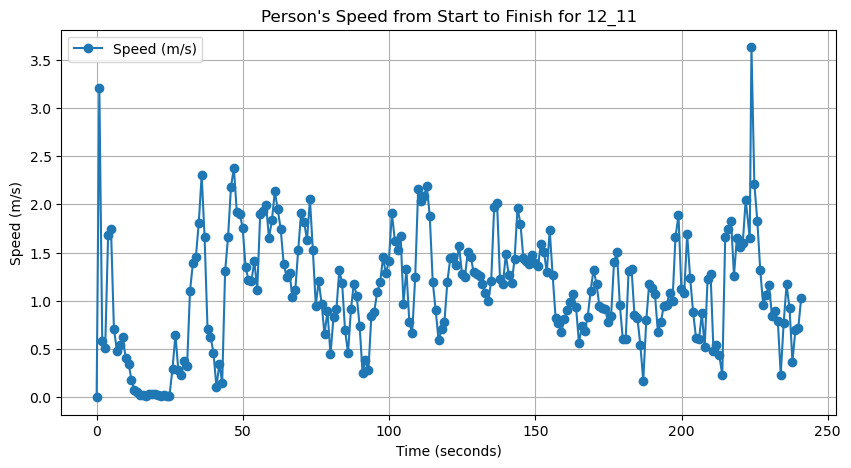

Total distance traveled for 12_1: 402.64 meters


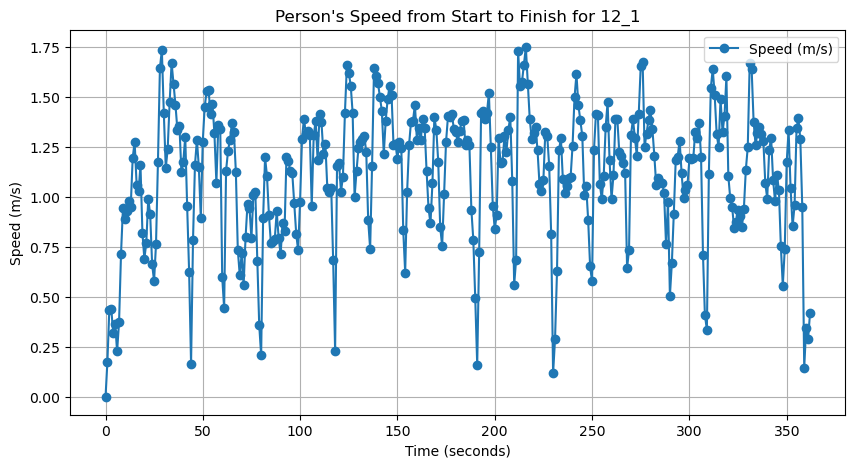

Total distance traveled for 12_6: 255.49 meters


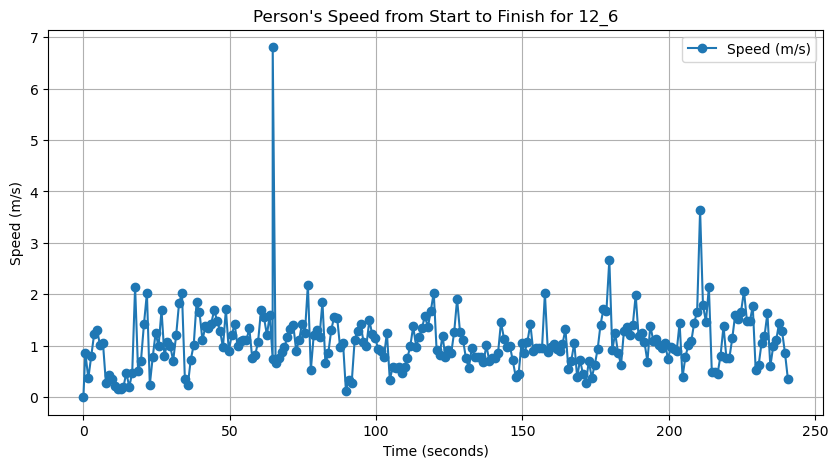

Total distance traveled for 12_8: 326.20 meters


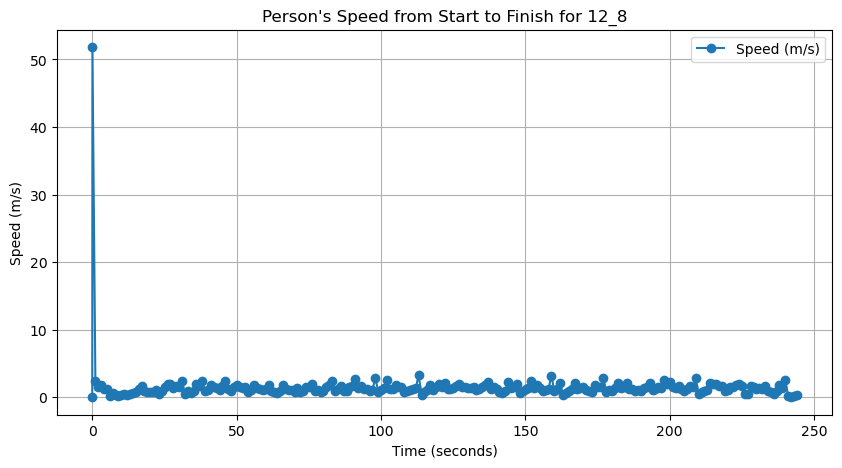

Total distance traveled for 12_9: 238.42 meters


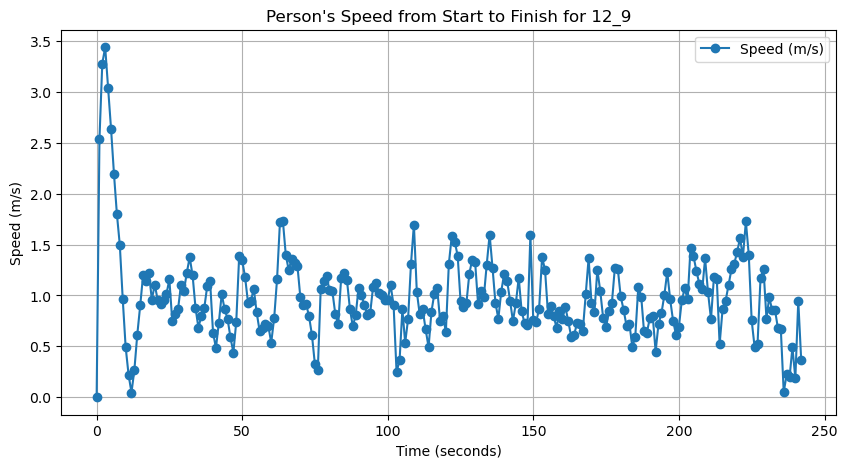

Total distance traveled for 12_7: 239.40 meters


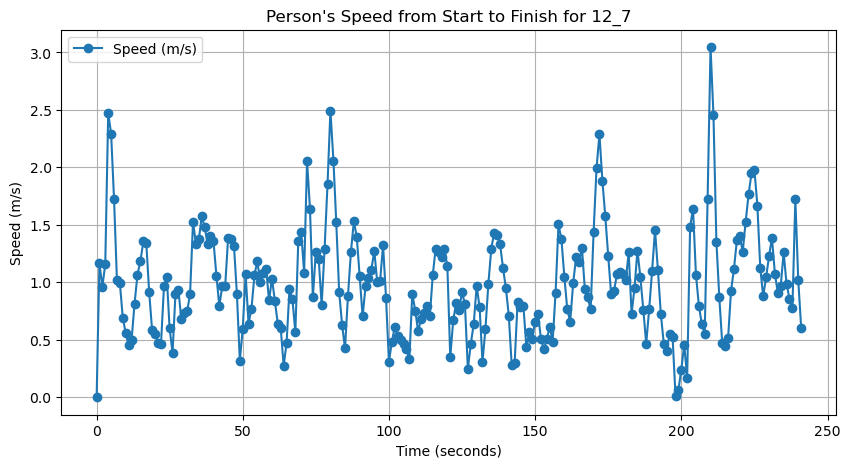

Total distance traveled for 12_0: 502.63 meters


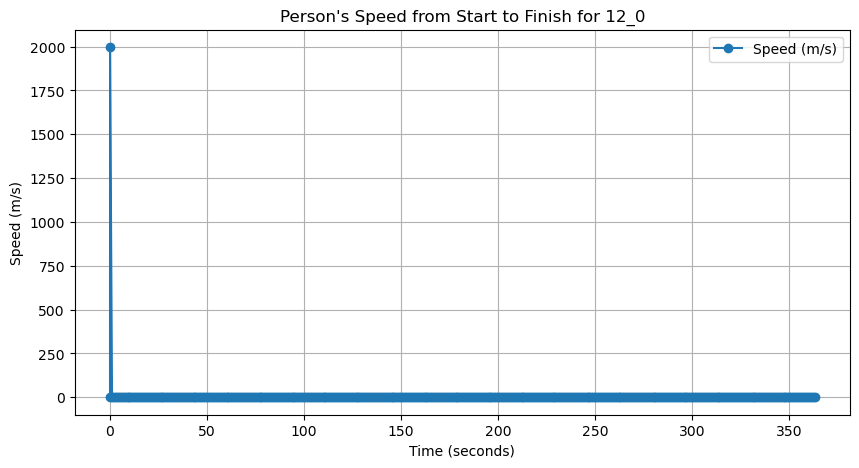

Total distance traveled for 12_13: 143.71 meters


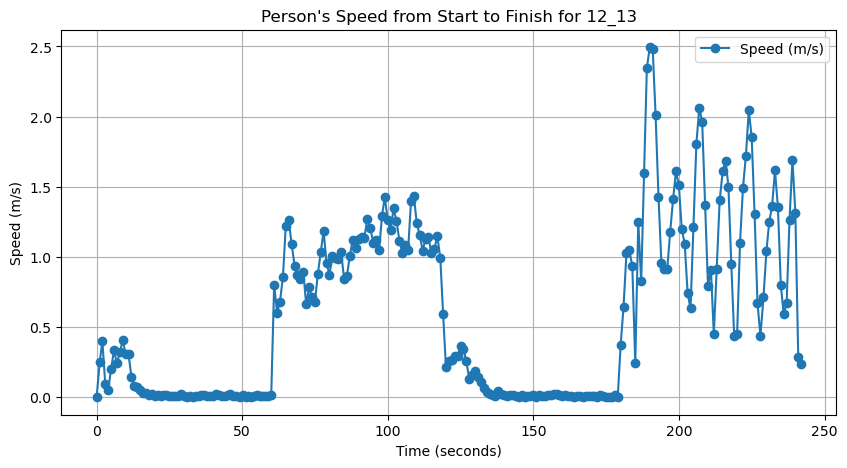

Total distance traveled for 12_12: 198.97 meters


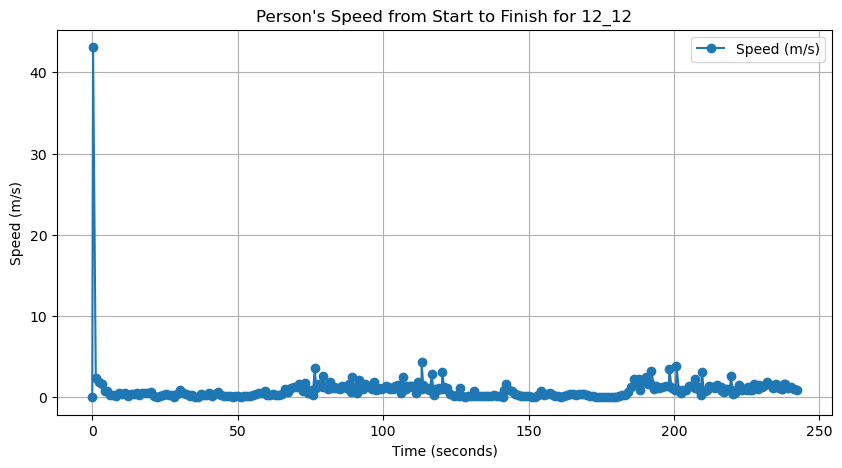

Total distance traveled for 14_9: 1152.09 meters


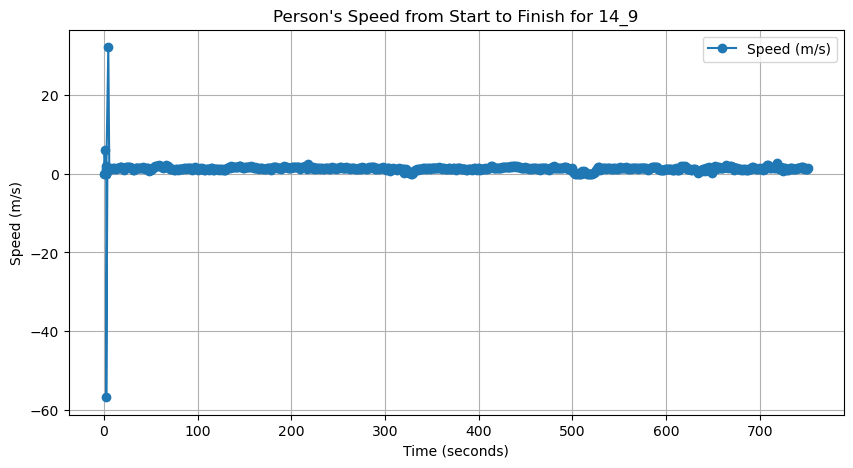

Total distance traveled for 14_0: 1066.28 meters


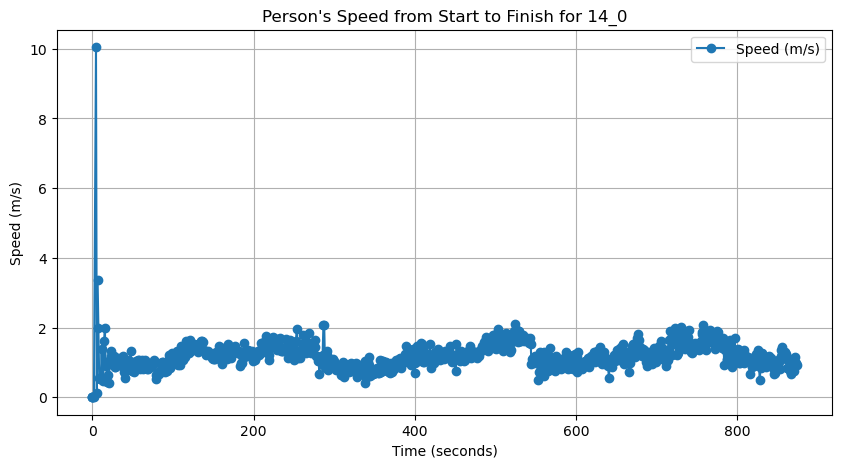

Total distance traveled for 14_7: 1111.73 meters


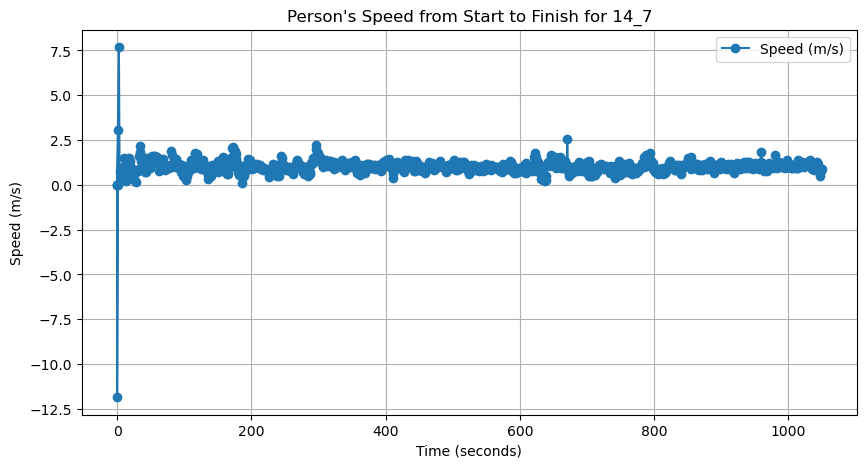

Total distance traveled for 14_6: 1265.65 meters


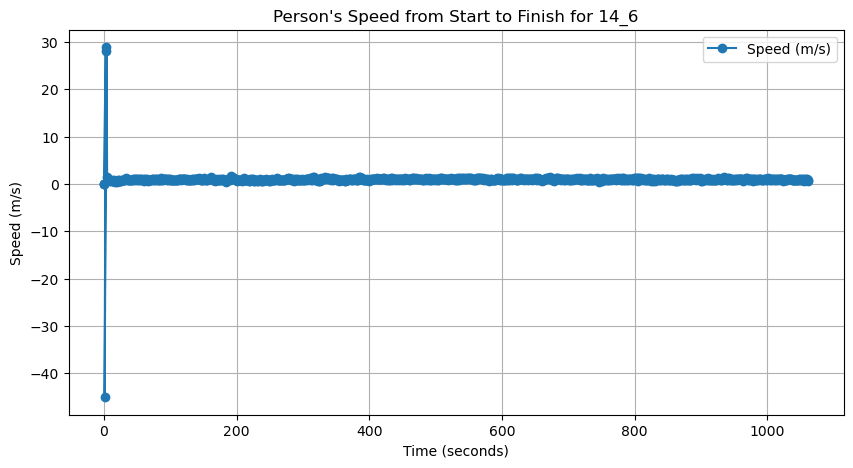

Total distance traveled for 14_1: 1132.85 meters


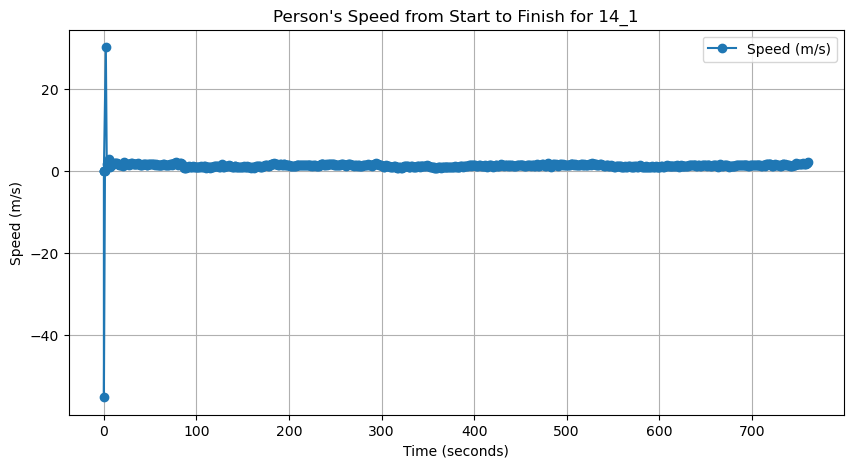

Total distance traveled for 14_8: 1389.72 meters


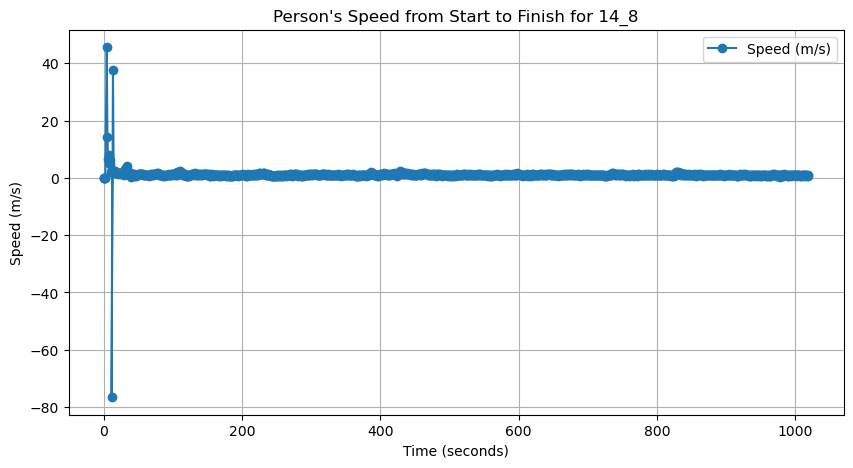

Total distance traveled for 14_14: 1108.89 meters


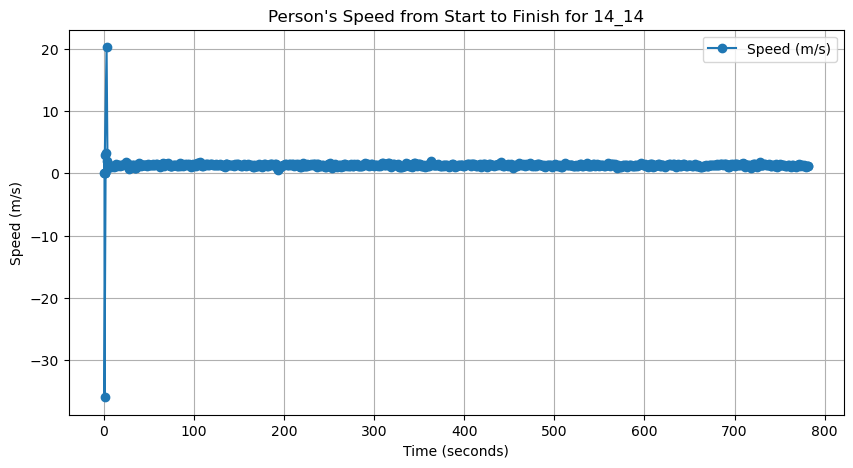

Total distance traveled for 14_13: 1084.48 meters


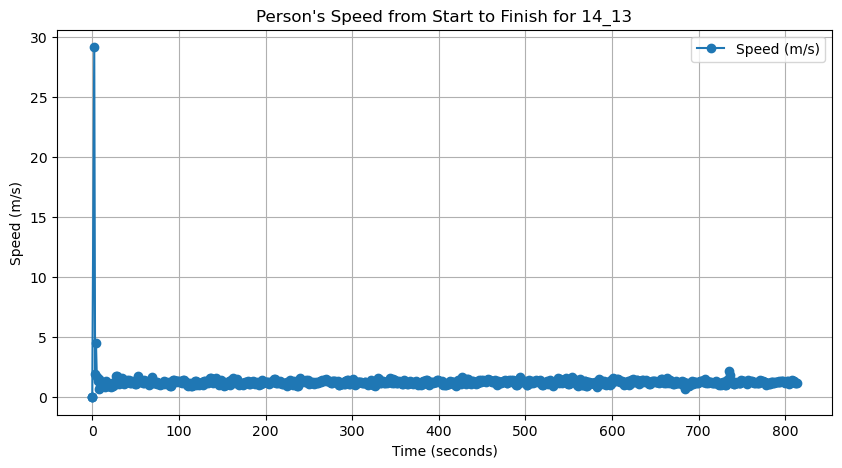

Total distance traveled for 14_12: 1211.24 meters


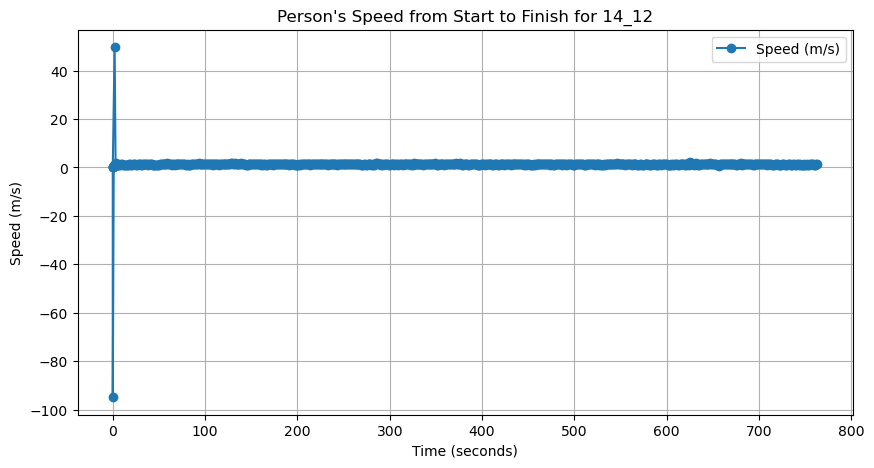

Total distance traveled for 14_4: 1059.44 meters


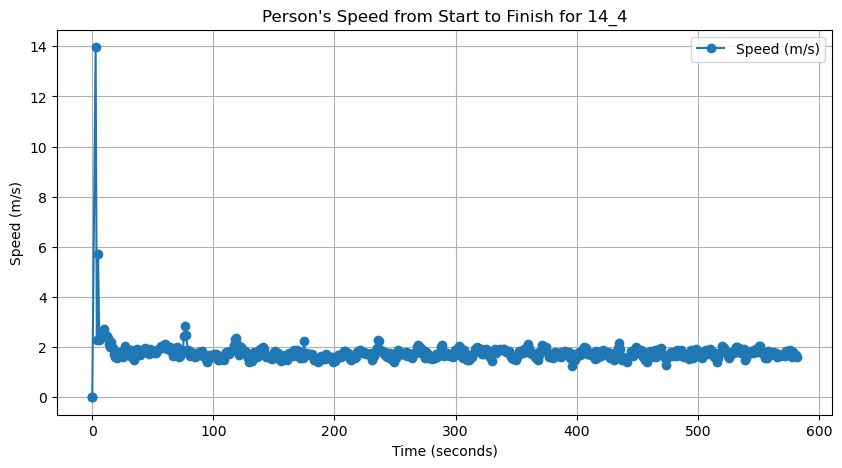

Total distance traveled for 14_3: 1116.61 meters


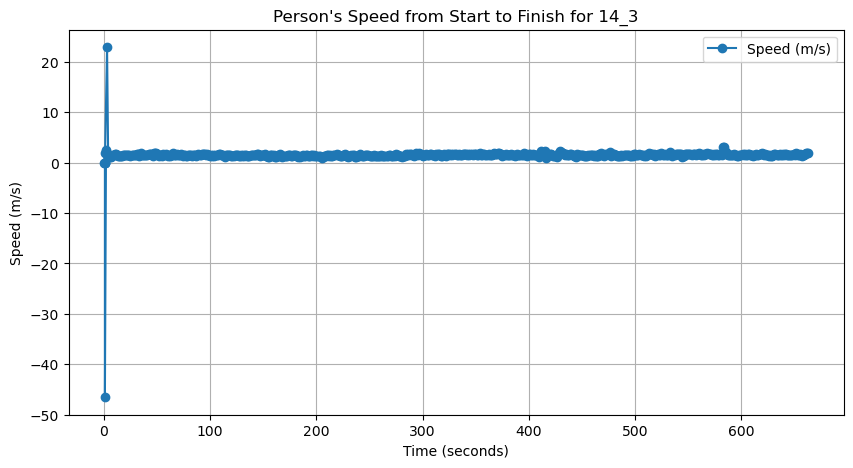

Total distance traveled for 14_2: 1400.49 meters


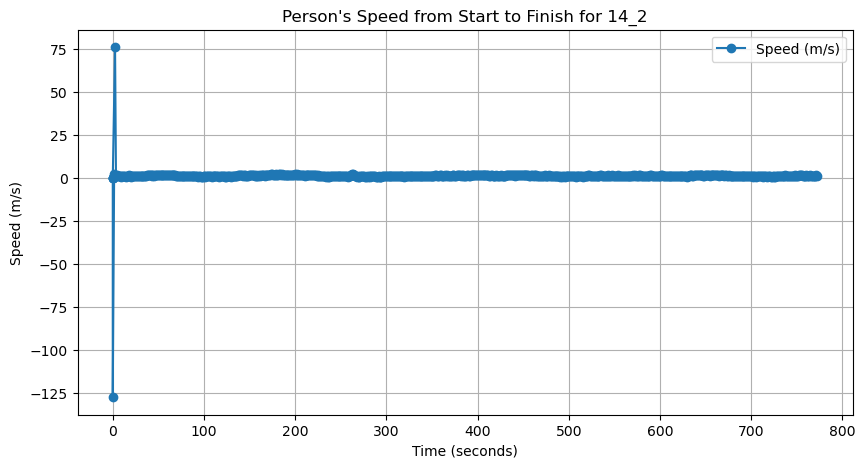

Total distance traveled for 14_5: 1068.27 meters


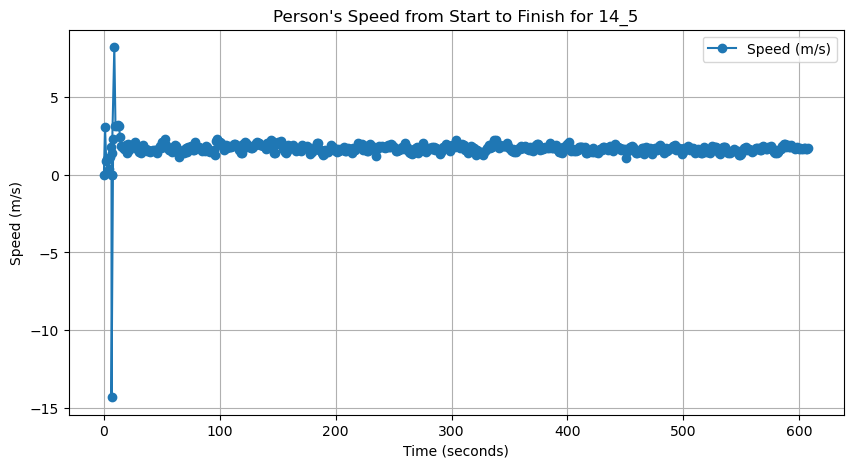

Total distance traveled for 14_10: 1150.66 meters


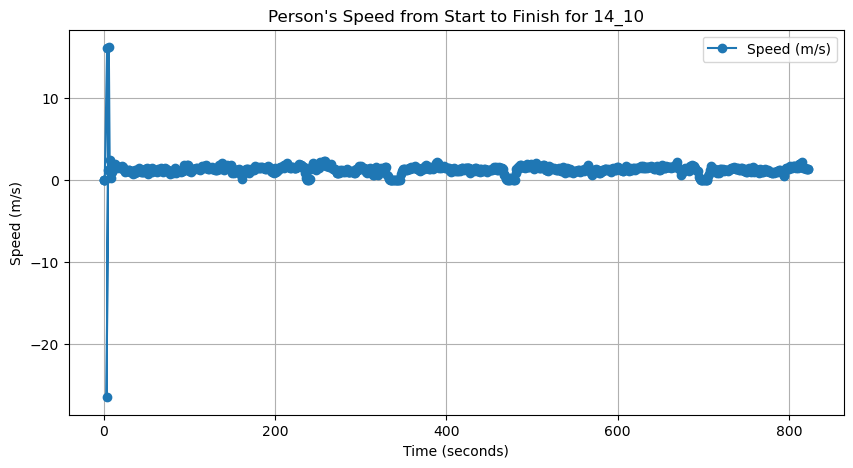

Total distance traveled for 14_11: 1101.43 meters


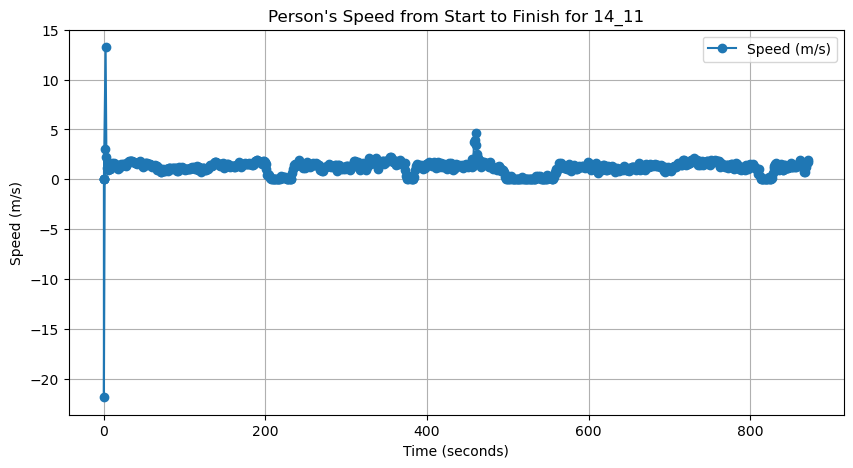

Total distance traveled for 13_11: 368.60 meters


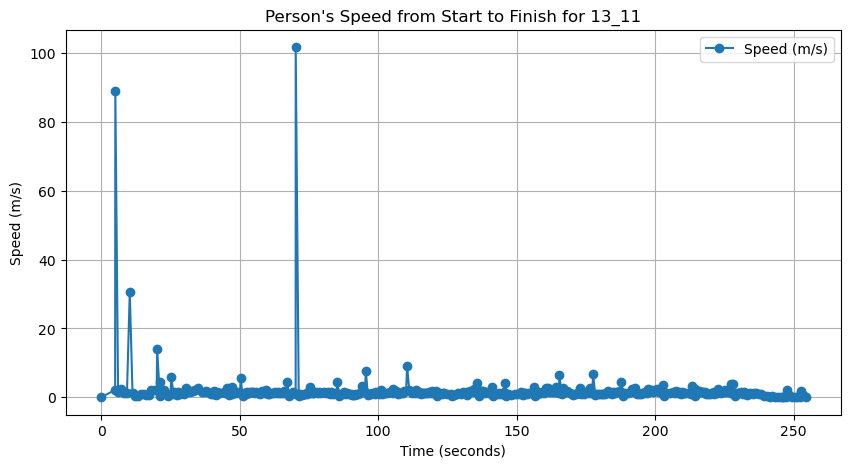

Total distance traveled for 13_10: 298.74 meters


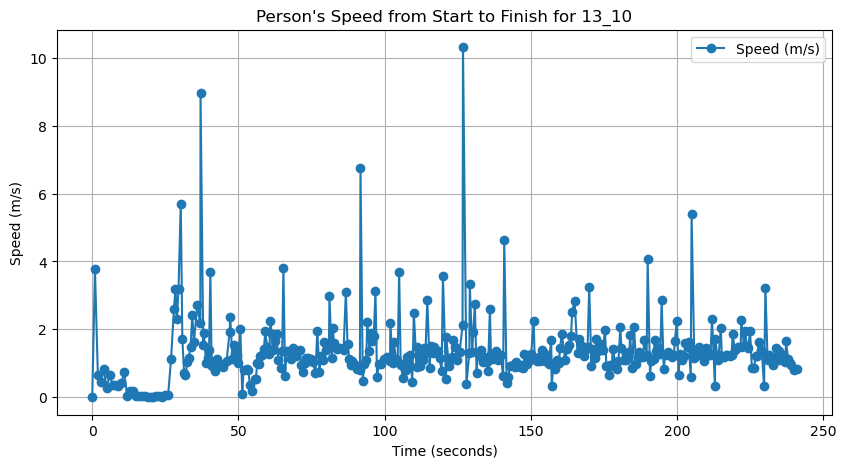

Total distance traveled for 13_8: 308.11 meters


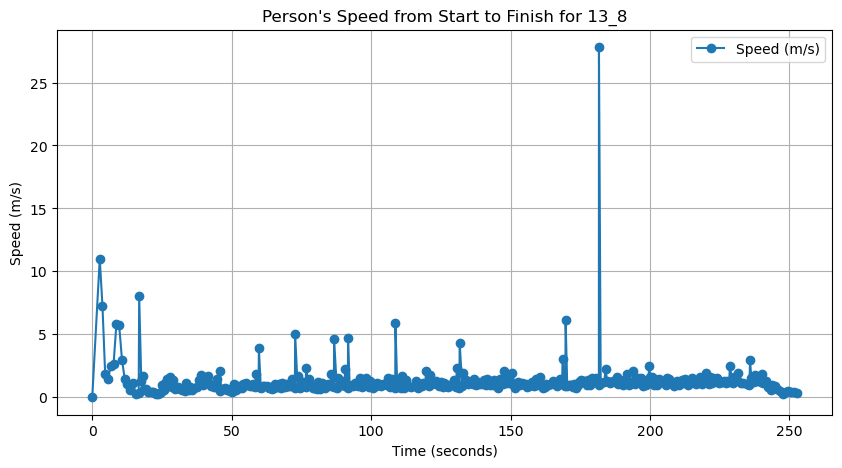

Total distance traveled for 13_6: 313.93 meters


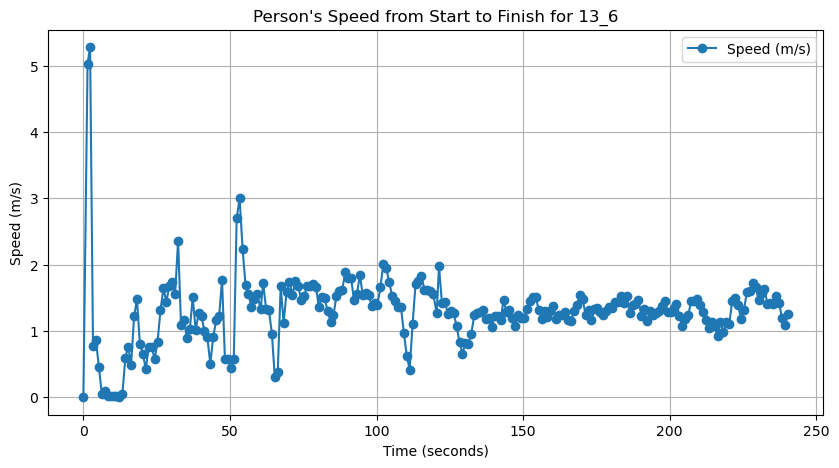

Total distance traveled for 13_1: 601.31 meters


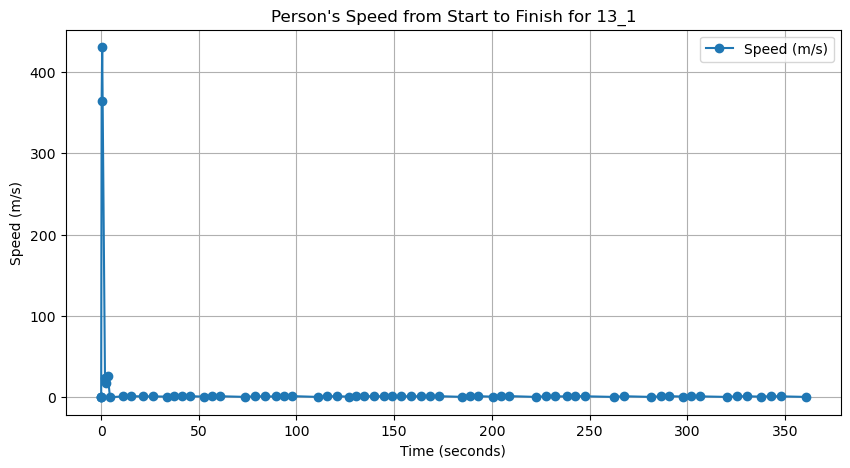

Total distance traveled for 13_0: 449.23 meters


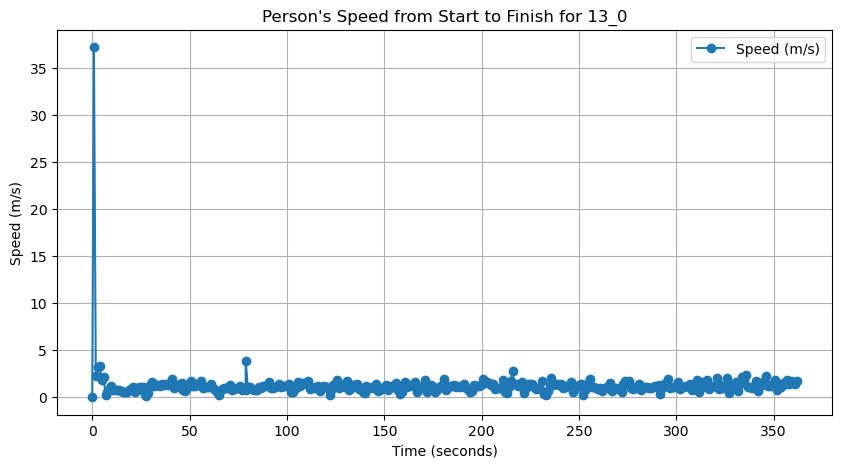

Total distance traveled for 13_7: 236.99 meters


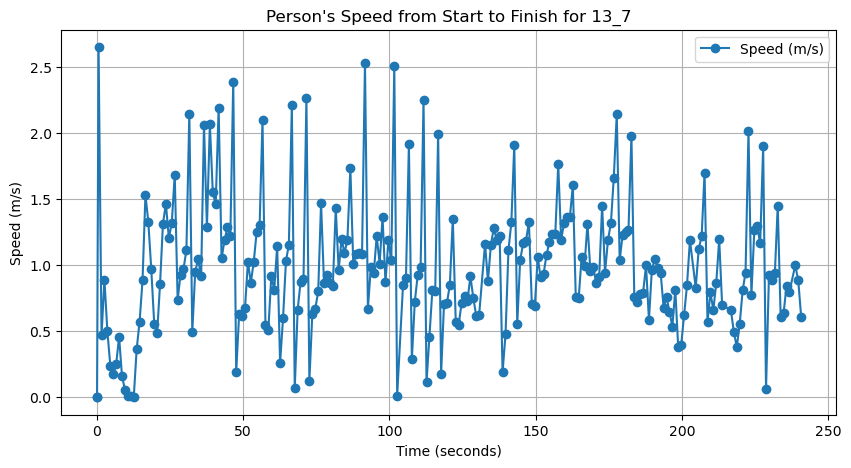

Total distance traveled for 13_9: 309.41 meters


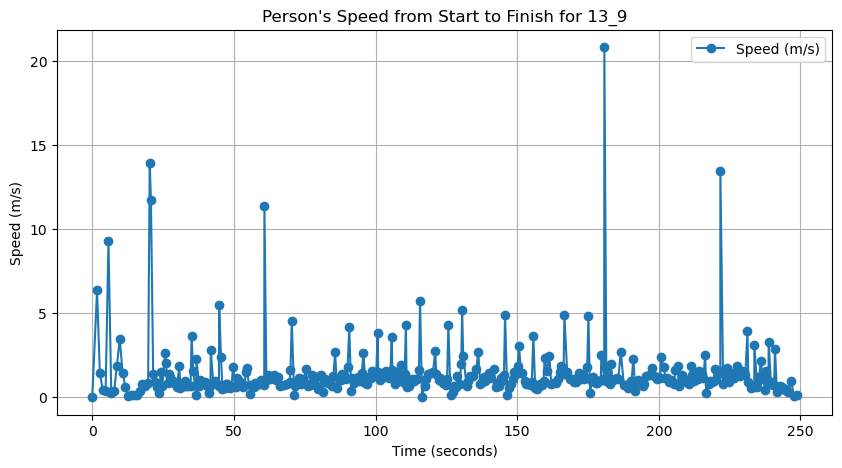

Total distance traveled for 13_12: 166.83 meters


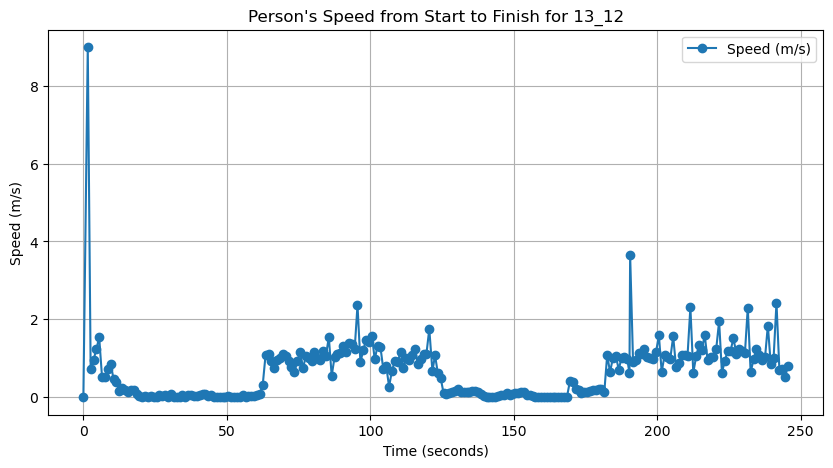

Total distance traveled for 13_13: 331.18 meters


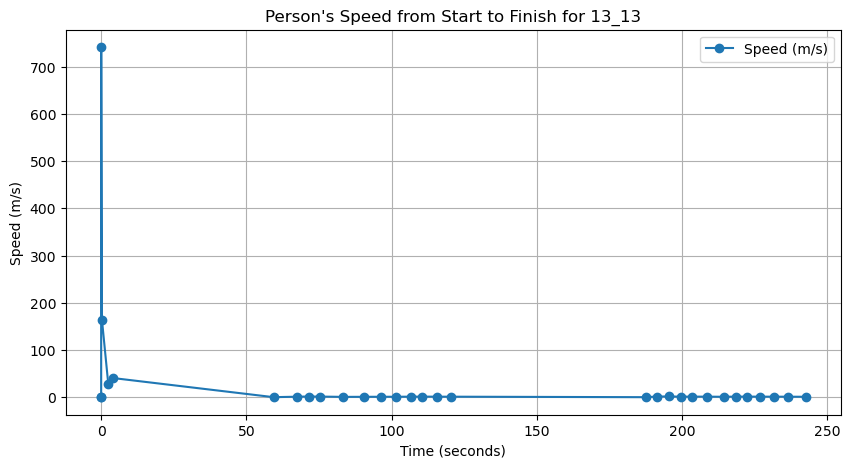

Total distance traveled for 13_2: 531.85 meters


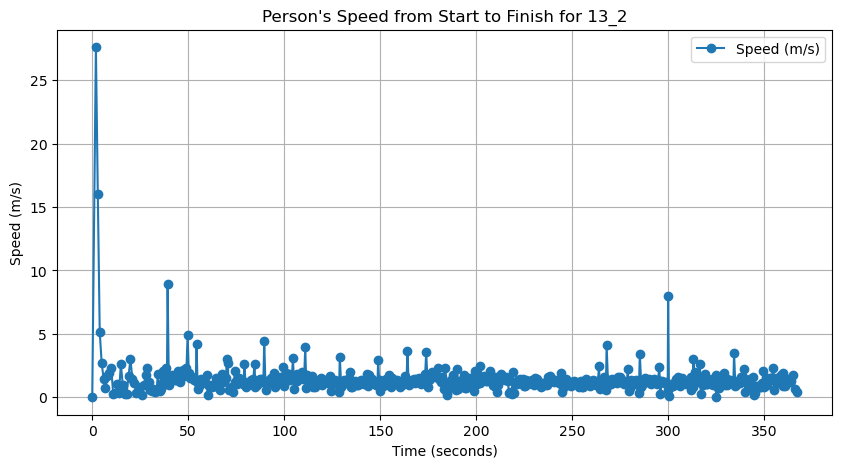

Total distance traveled for 13_5: 352.85 meters


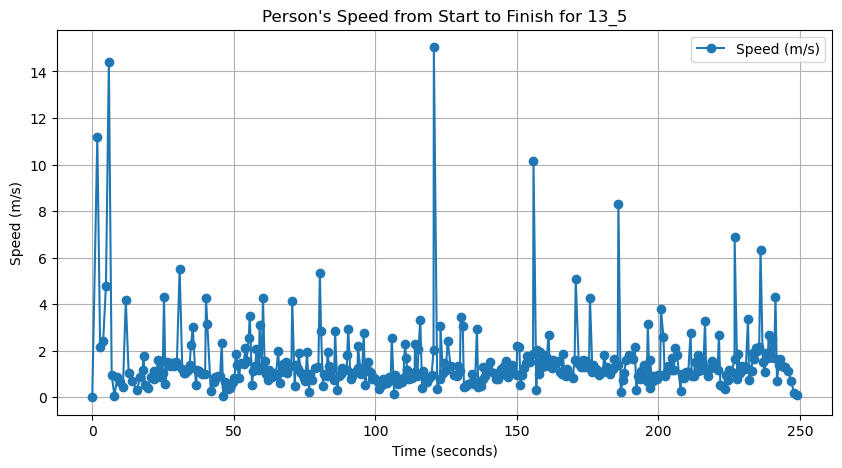

Total distance traveled for 13_4: 356.62 meters


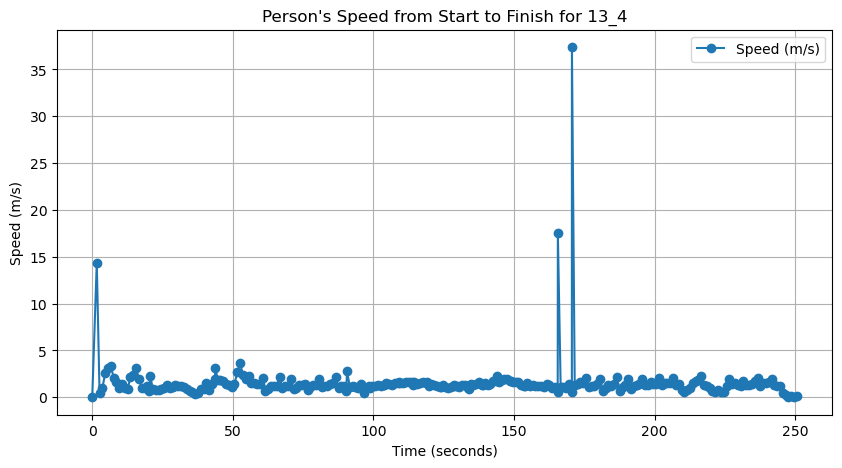

Total distance traveled for 13_3: 685.15 meters


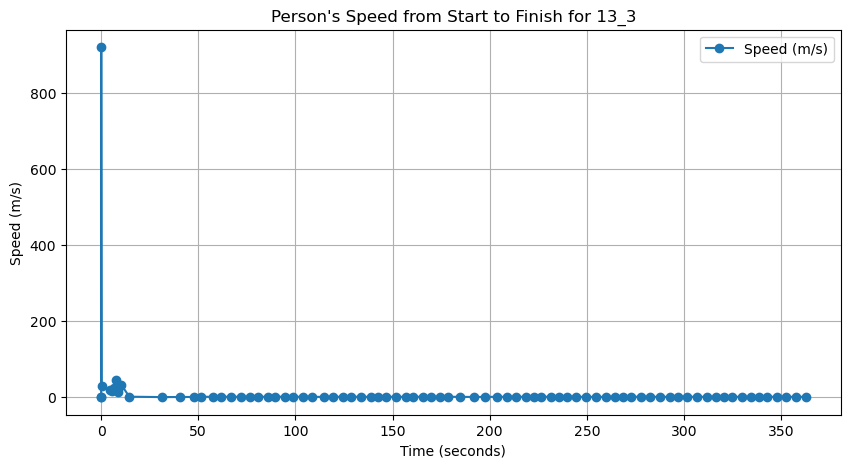

Total distance traveled for 4_2: 466.87 meters


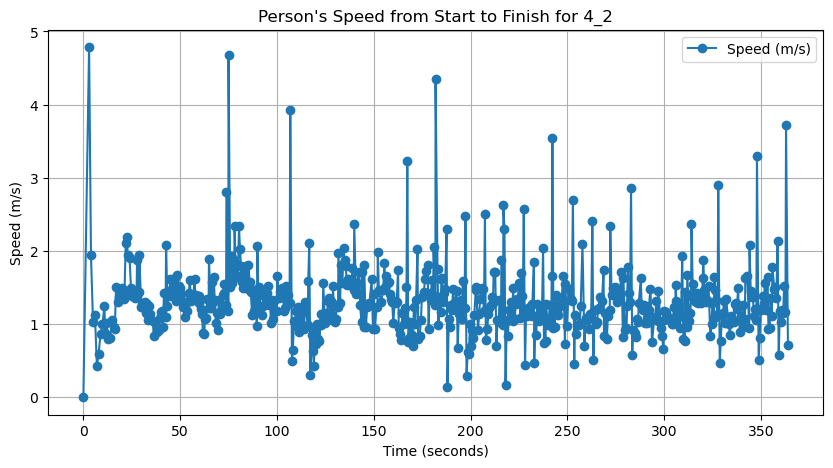

Total distance traveled for 4_5: 425.23 meters


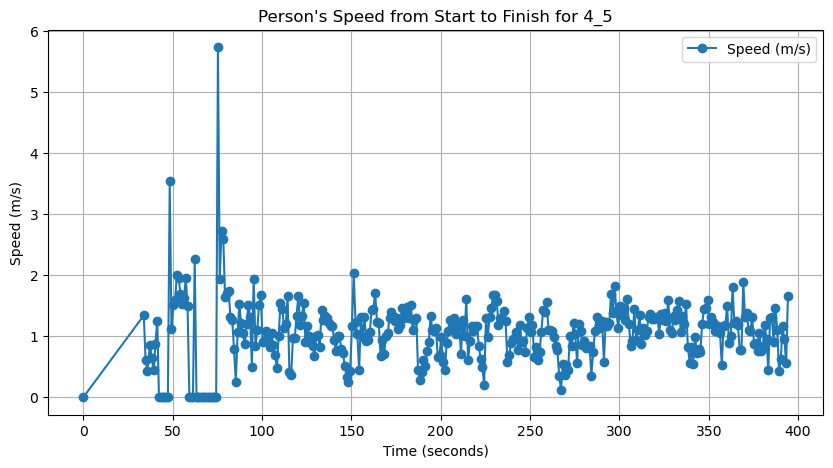

Total distance traveled for 4_4: 564.10 meters


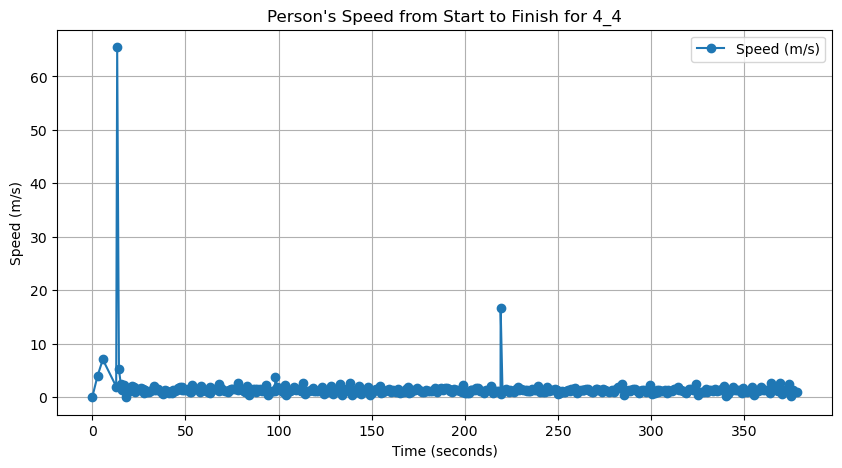

Total distance traveled for 4_3: 462.16 meters


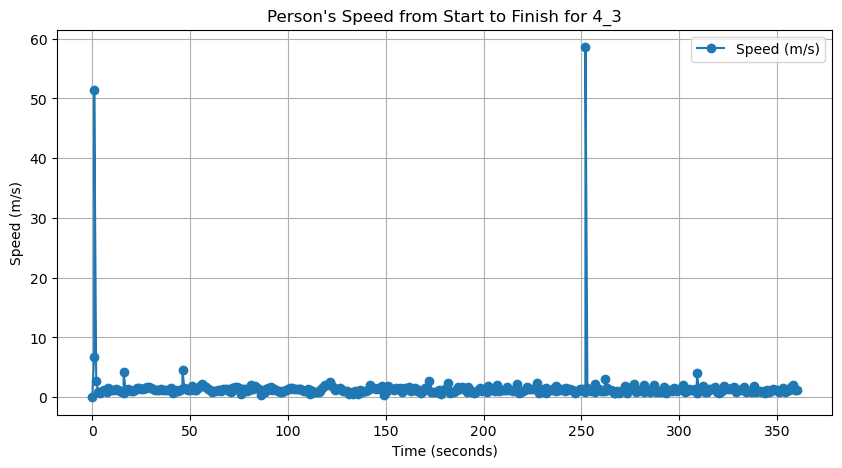

Total distance traveled for 4_6: 393.34 meters


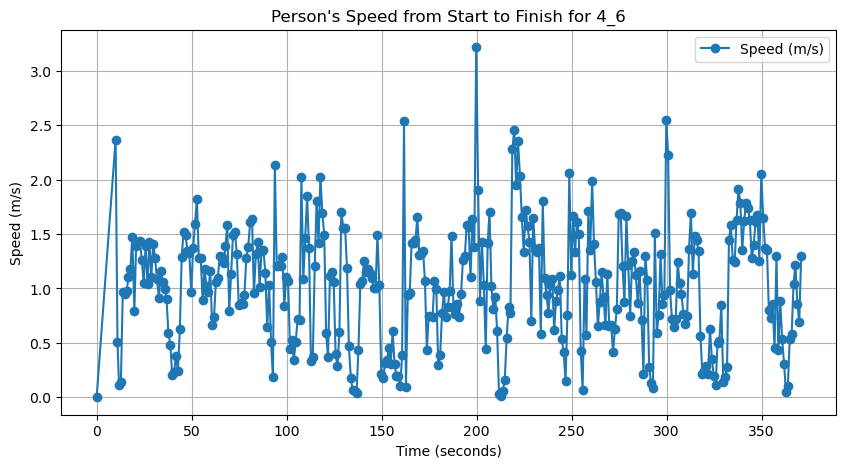

Total distance traveled for 4_1: 536.92 meters


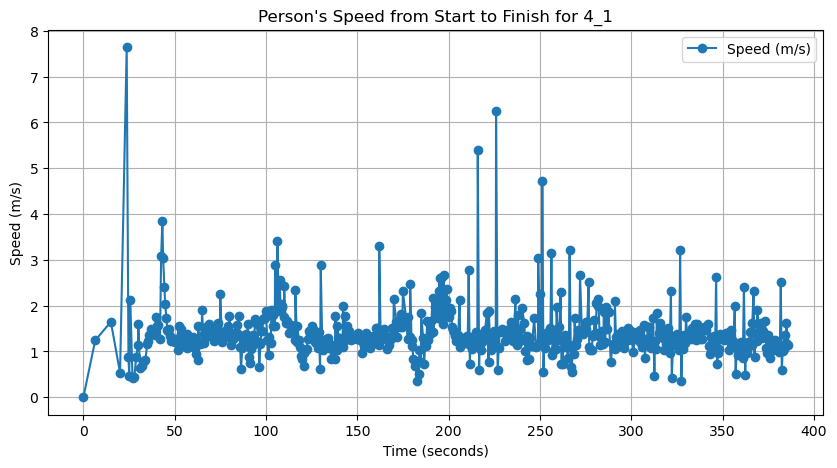

Total distance traveled for 4_8: 679.20 meters


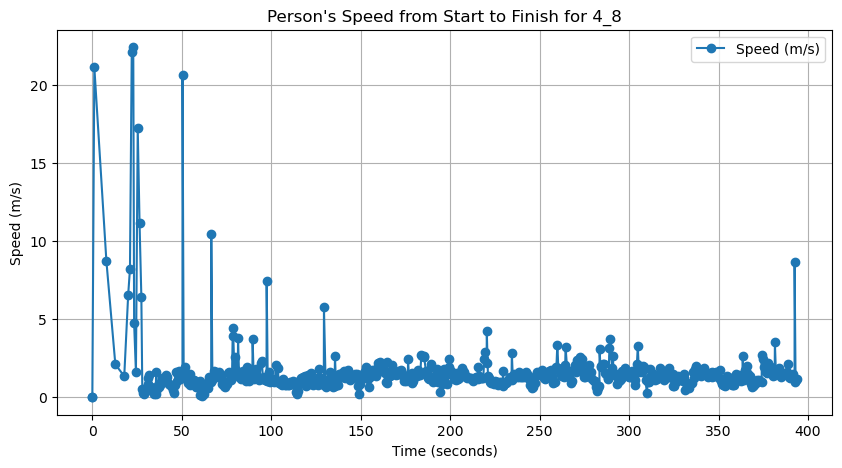

Total distance traveled for 4_9: 489.03 meters


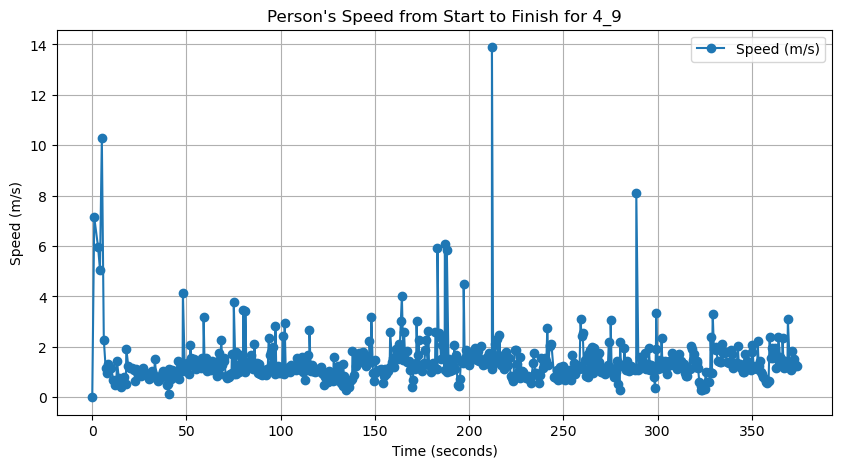

Total distance traveled for 4_0: 547.94 meters


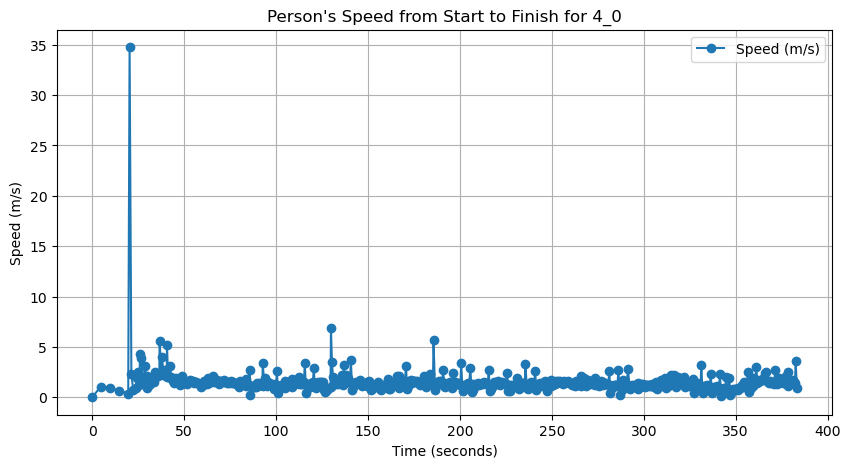

Total distance traveled for 4_7: 339.83 meters


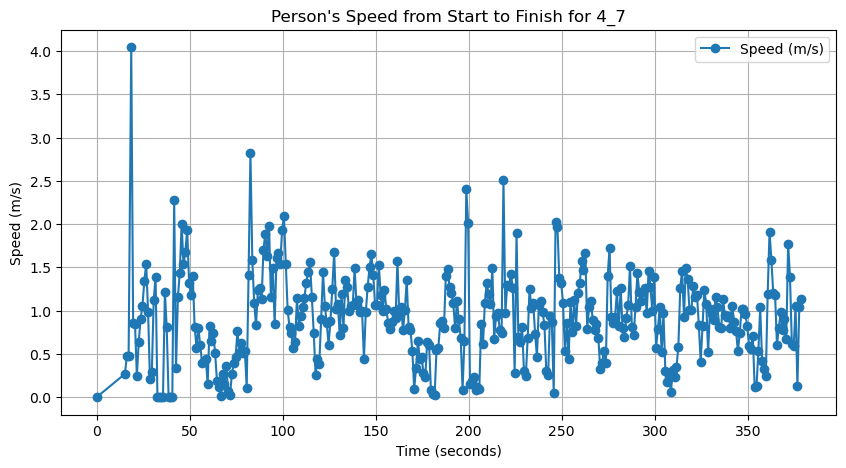

Total distance traveled for 3_4: 614.26 meters


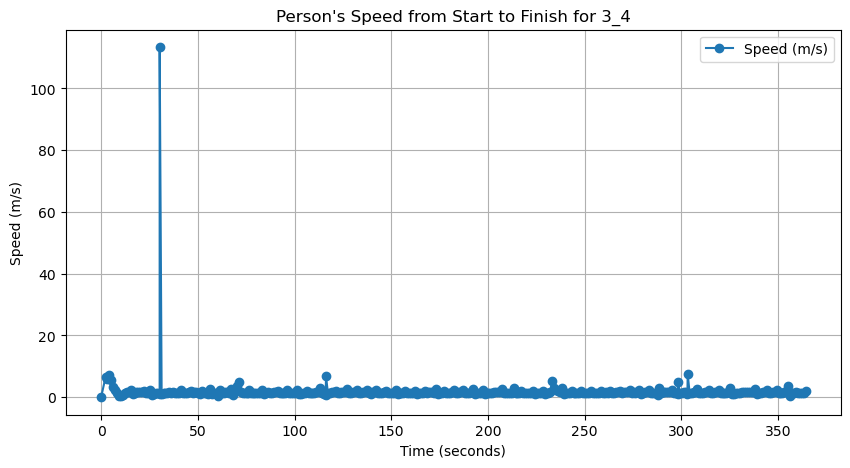

Total distance traveled for 3_3: 787.74 meters


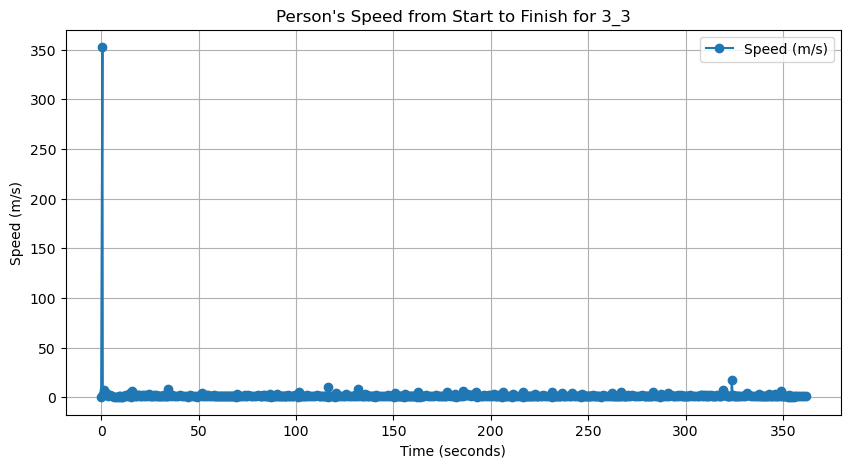

Total distance traveled for 3_2: 1050.91 meters


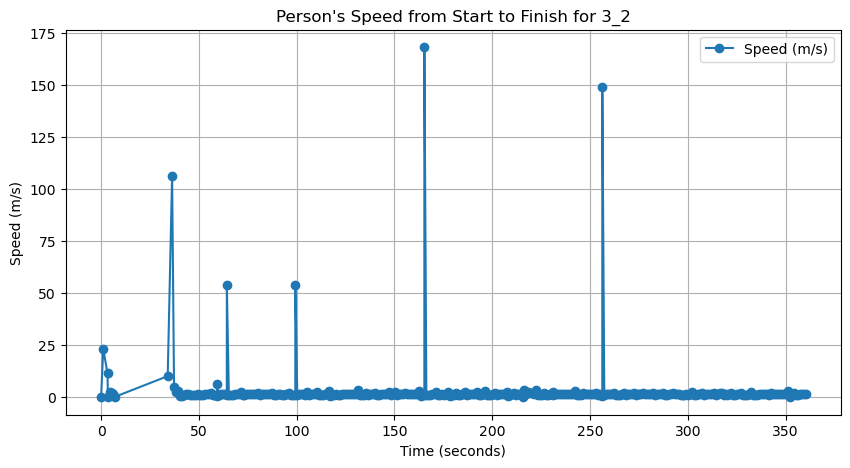

Total distance traveled for 3_1: 653.05 meters


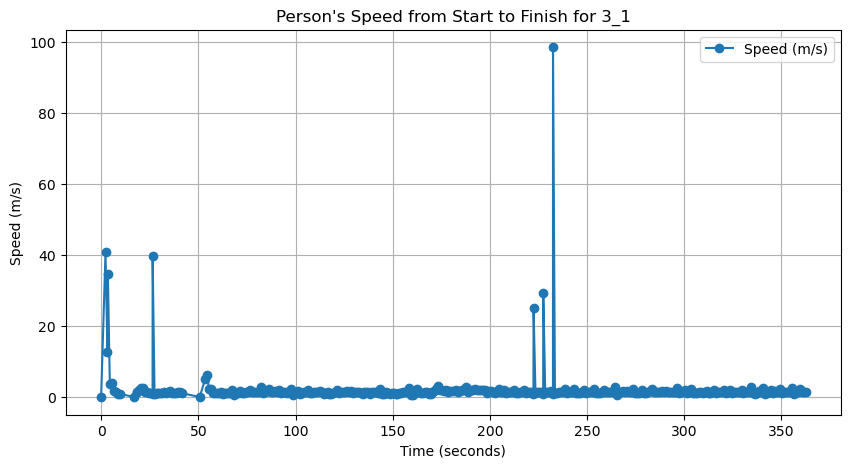

Total distance traveled for 5_8: 331.98 meters


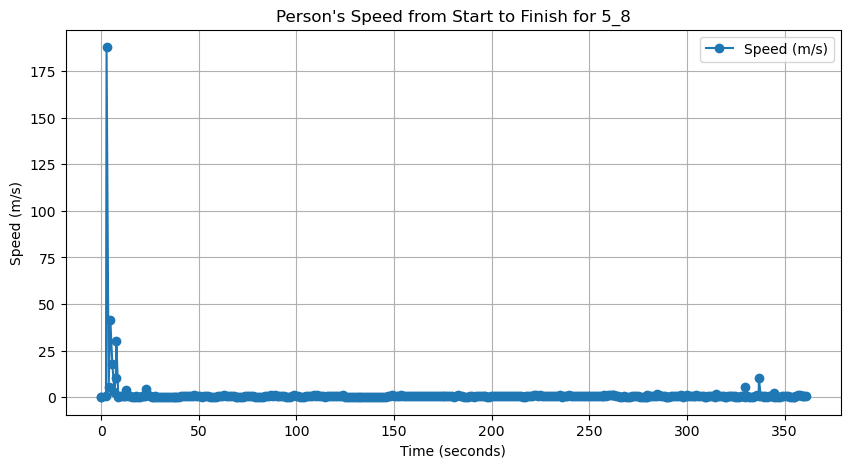

Total distance traveled for 5_1: 343.56 meters


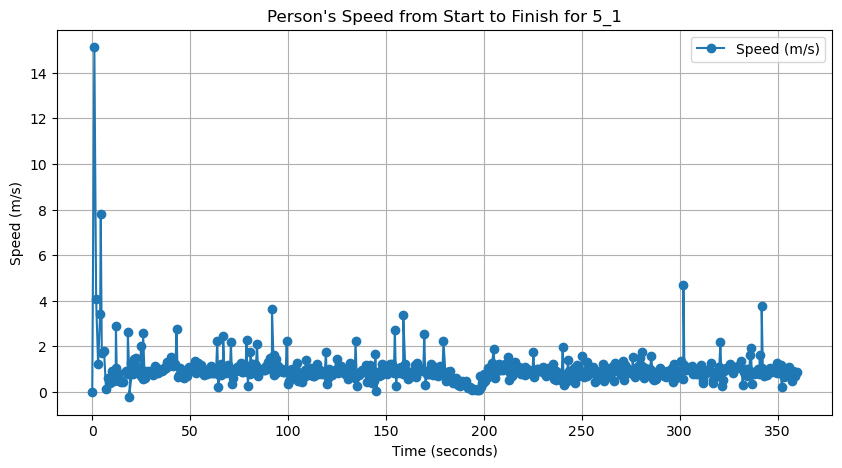

Total distance traveled for 5_6: 1469.10 meters


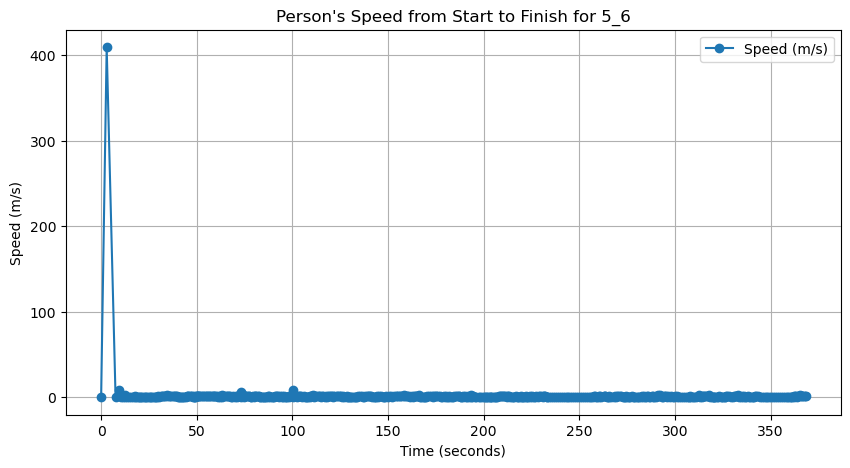

Total distance traveled for 5_7: 346.33 meters


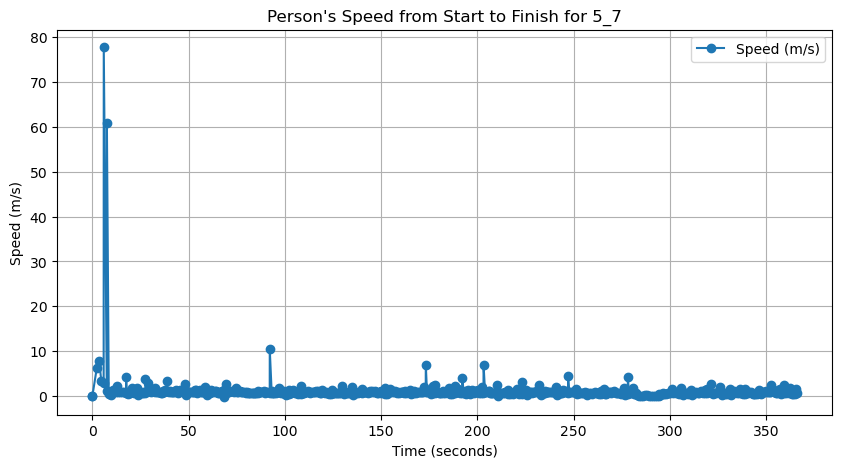

Total distance traveled for 5_0: 374.32 meters


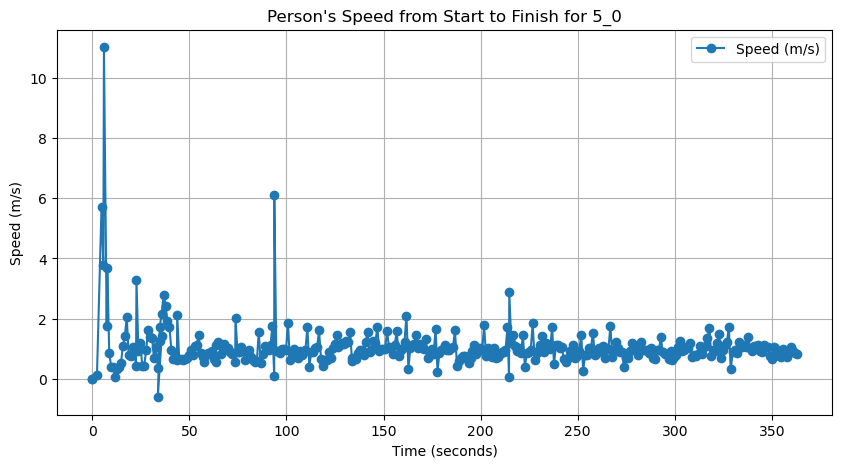

Total distance traveled for 5_9: 268.83 meters


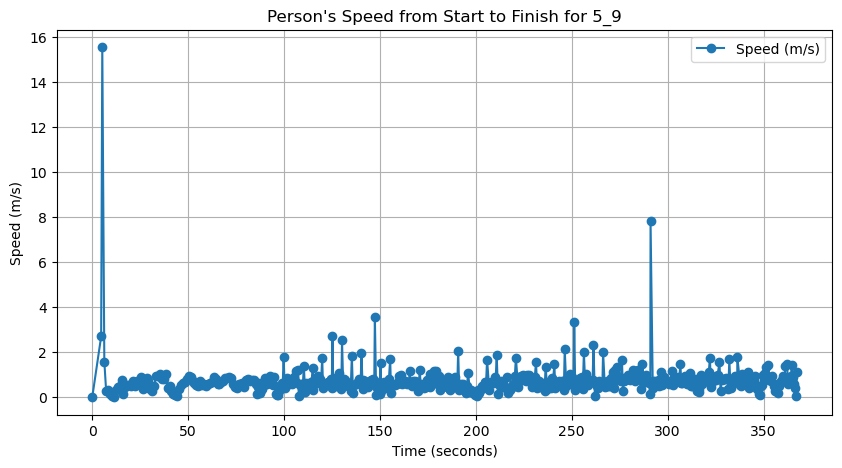

Total distance traveled for 5_5: 5480.73 meters


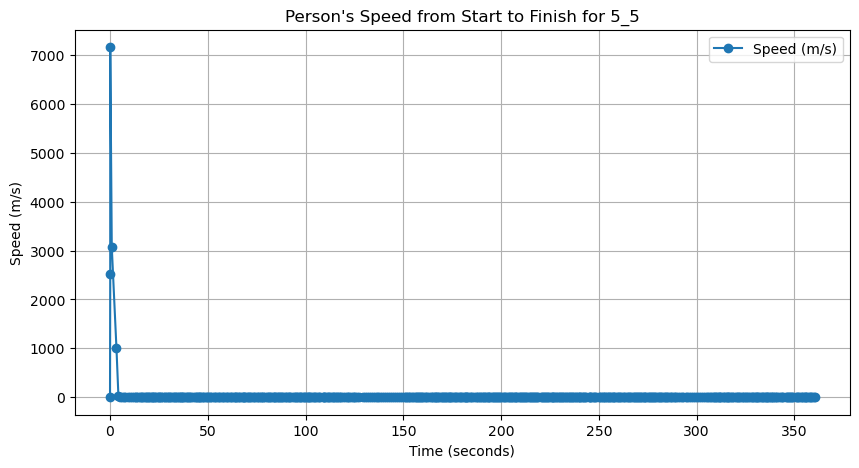

Total distance traveled for 5_2: 7784.81 meters


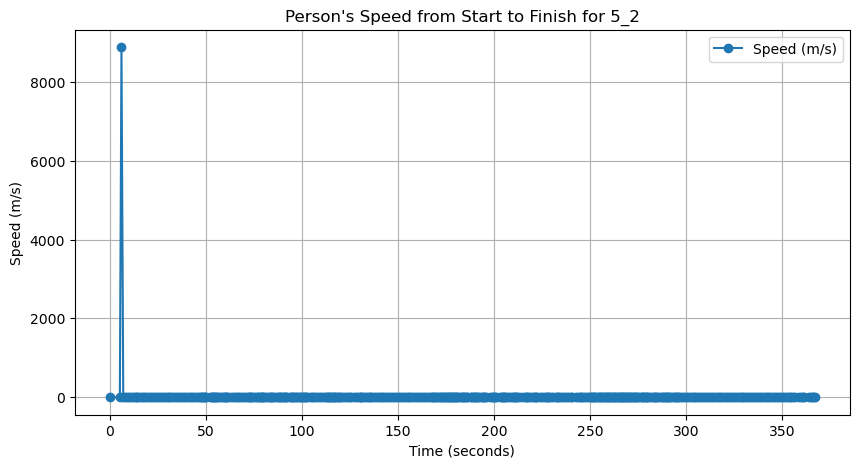

Total distance traveled for 5_3: 329.50 meters


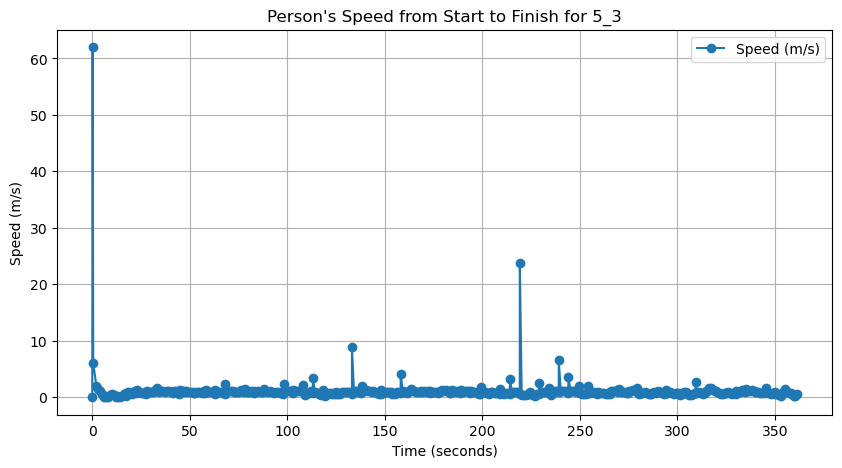

Total distance traveled for 5_4: 181.30 meters


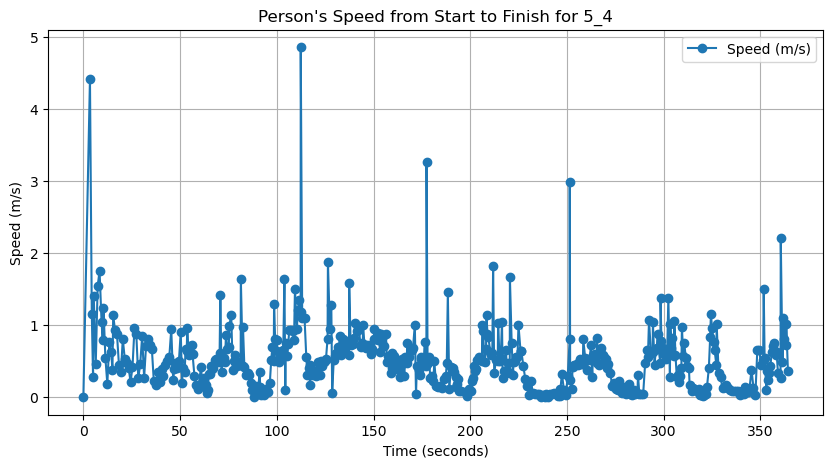

Total distance traveled for 16_3: 560.82 meters


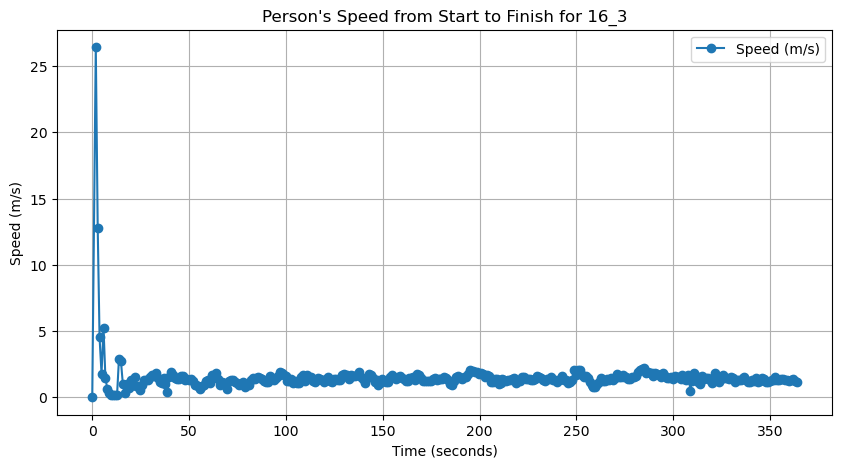

Total distance traveled for 16_4: 536.32 meters


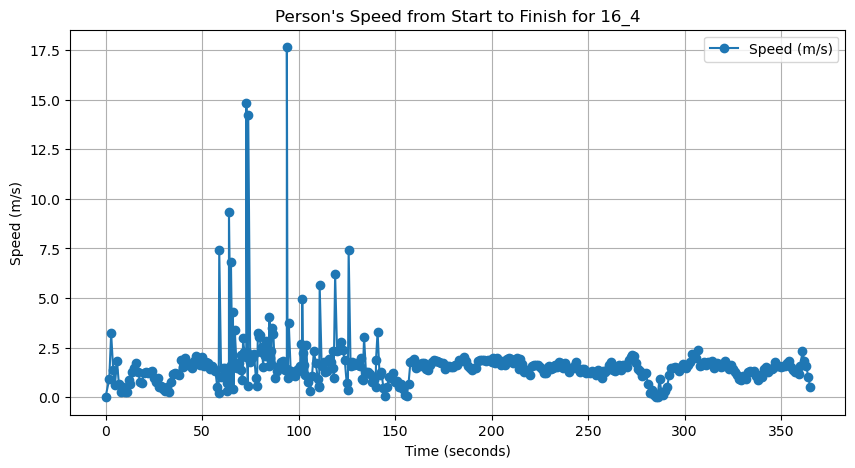

Total distance traveled for 16_2: 530.50 meters


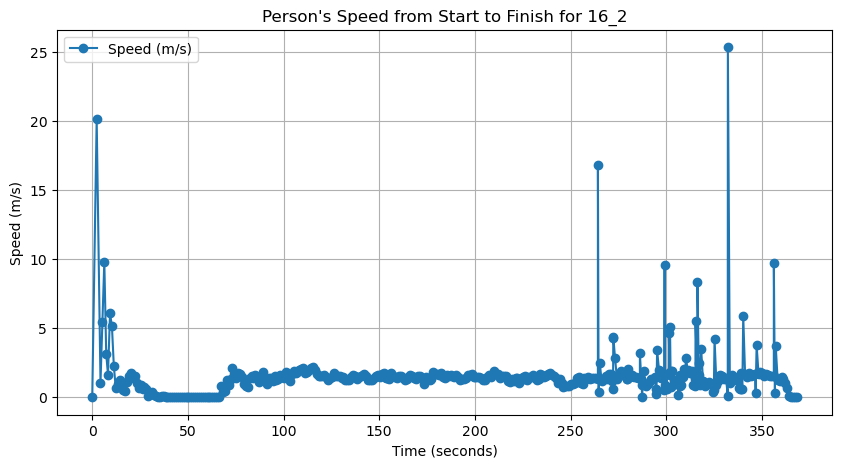

Total distance traveled for 16_0: 460.77 meters


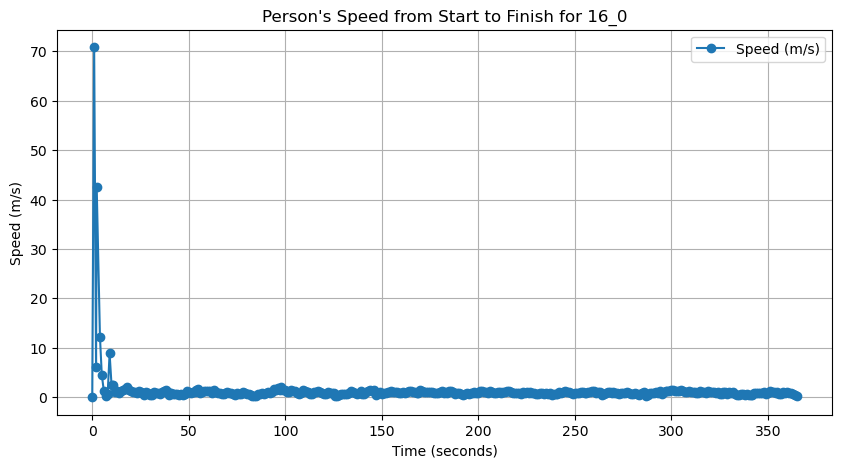

Total distance traveled for 16_1: 388.97 meters


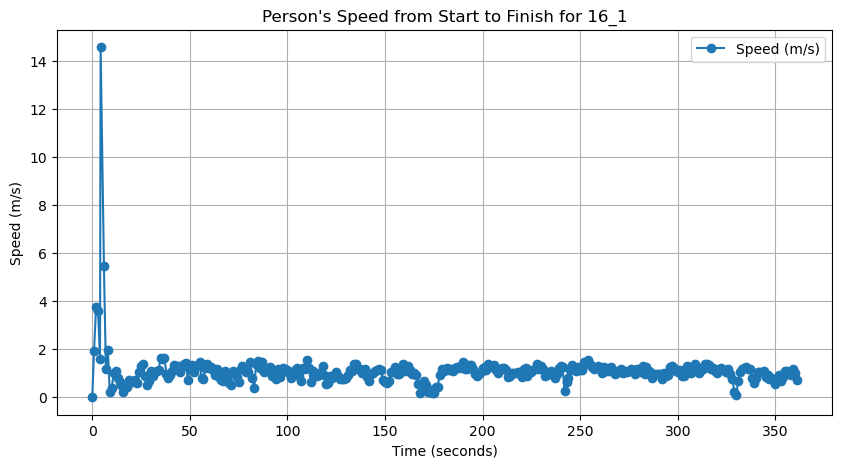

Total distance traveled for 11_5: 494.58 meters


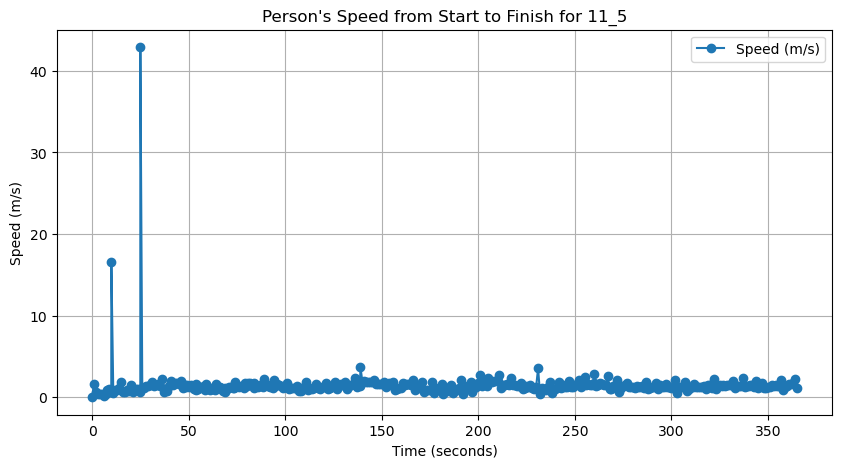

Total distance traveled for 11_2: 508.83 meters


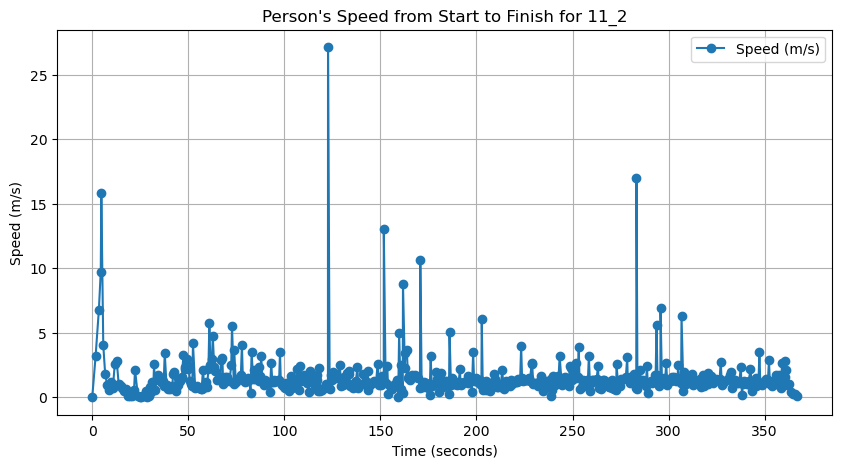

Total distance traveled for 11_13: 280.44 meters


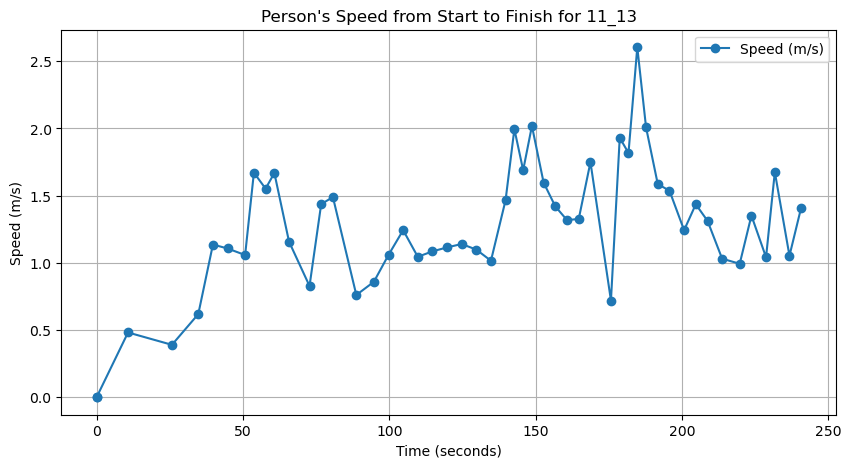

Total distance traveled for 11_14: 173.02 meters


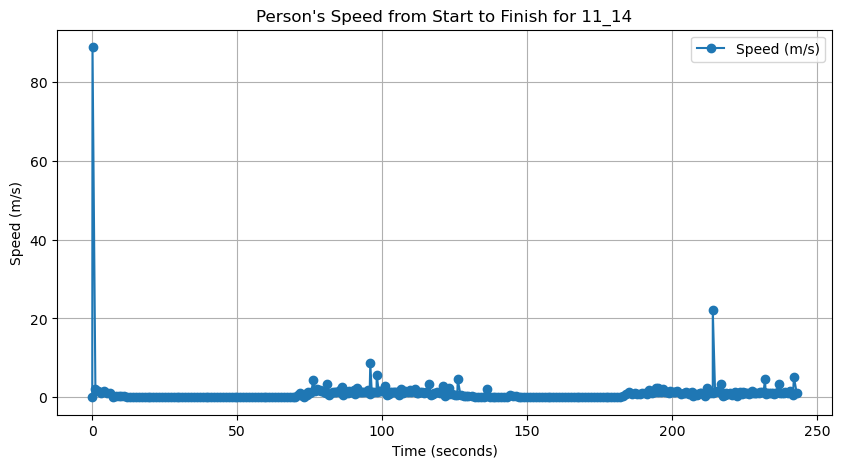

Total distance traveled for 11_3: 522.78 meters


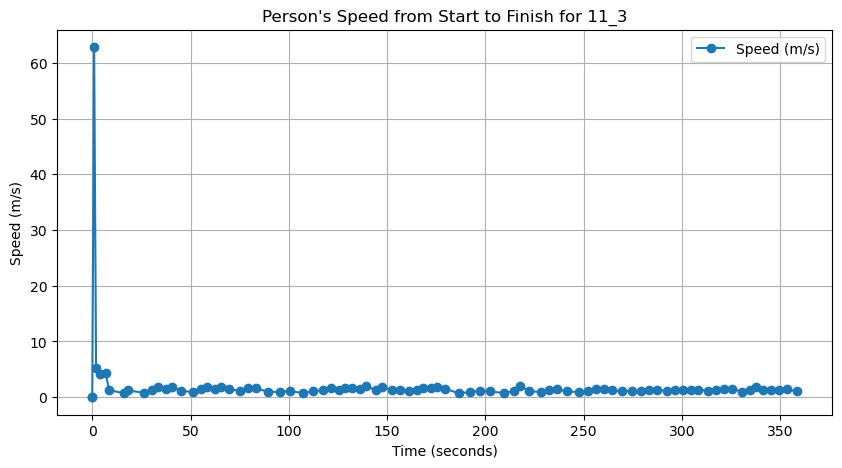

Total distance traveled for 11_4: 639.48 meters


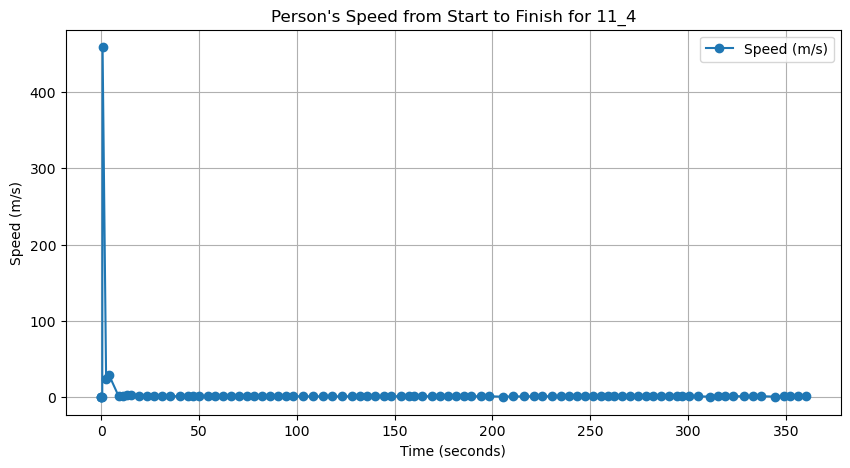

Total distance traveled for 11_15: 329.70 meters


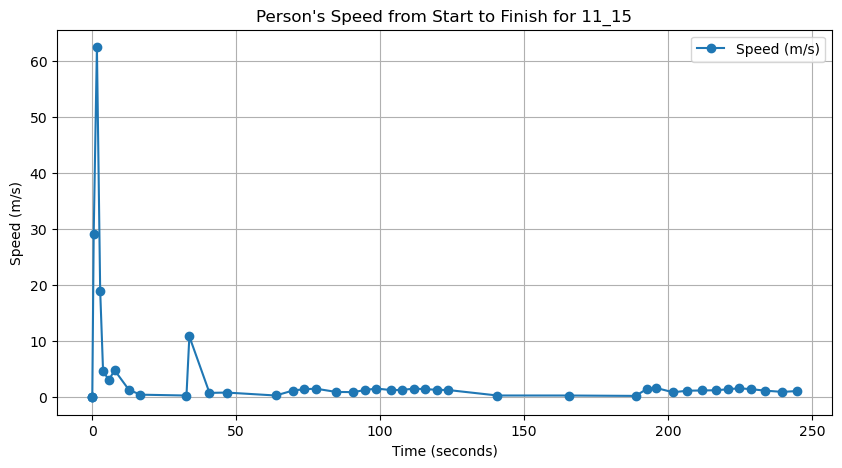

Total distance traveled for 11_12: 399.03 meters


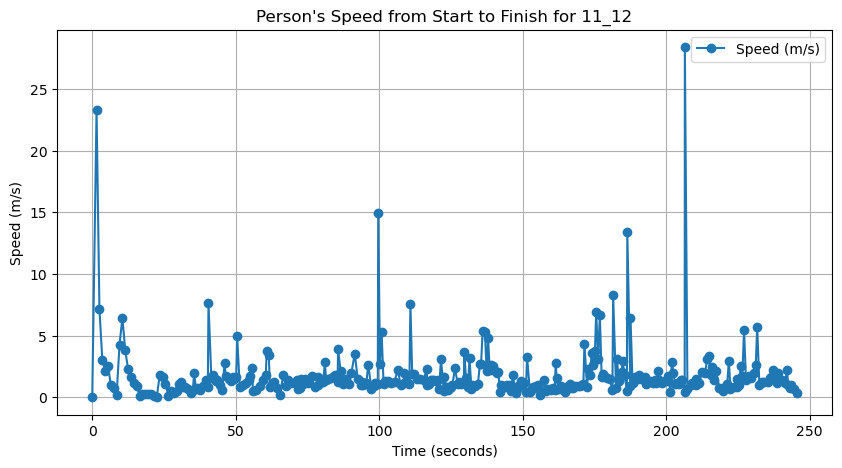

Total distance traveled for 11_10: 301.24 meters


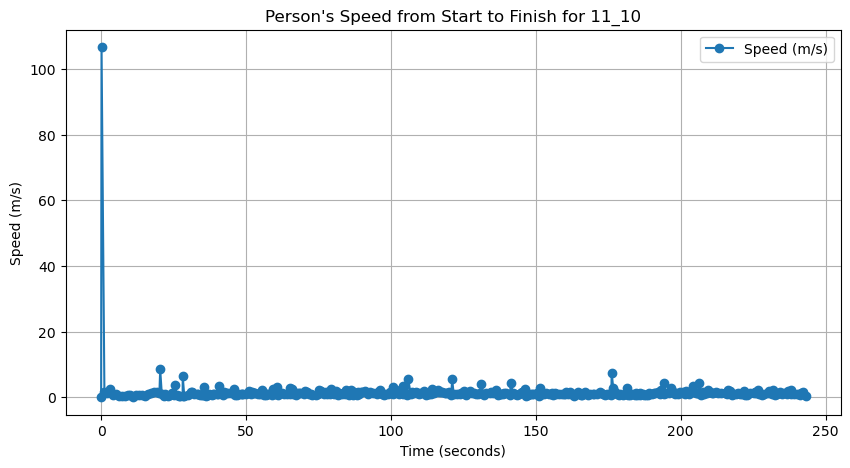

Total distance traveled for 11_1: 433.85 meters


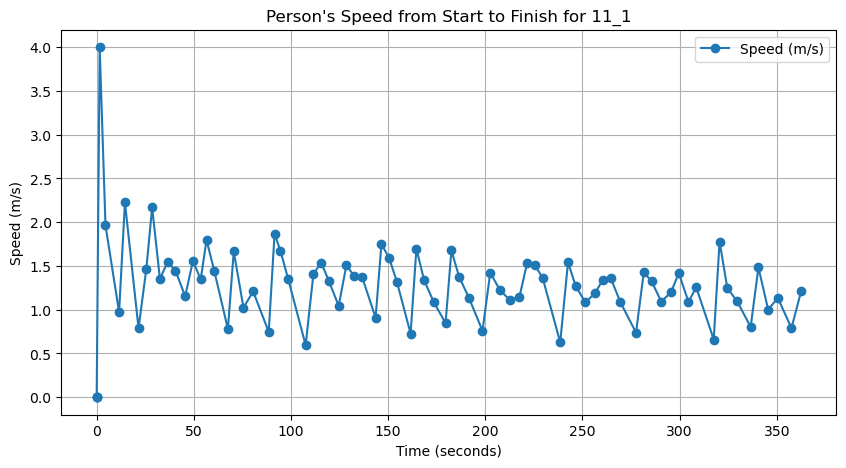

Total distance traveled for 11_6: 342.30 meters


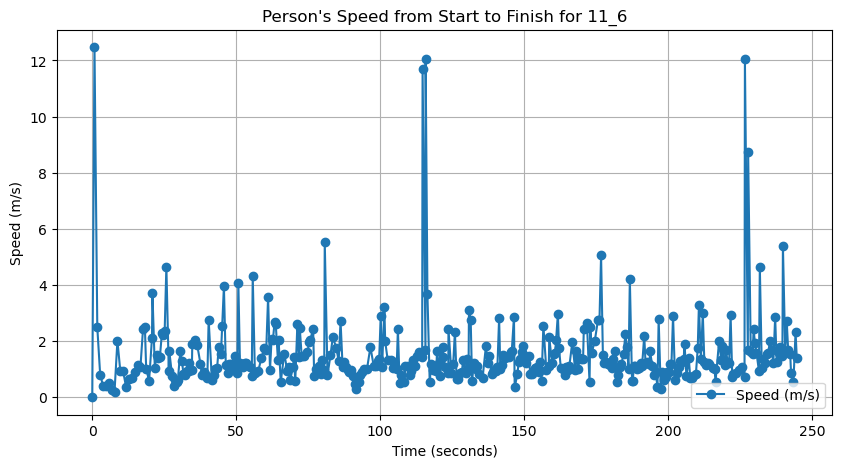

Total distance traveled for 11_8: 273.11 meters


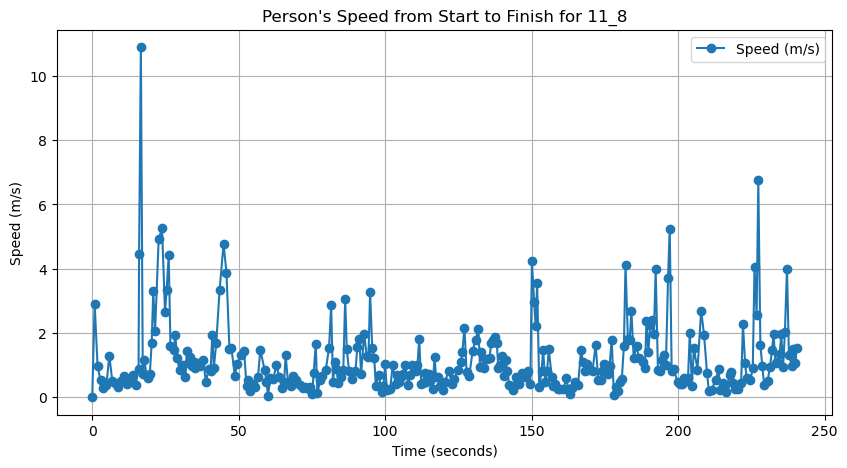

Total distance traveled for 11_11: 460.38 meters


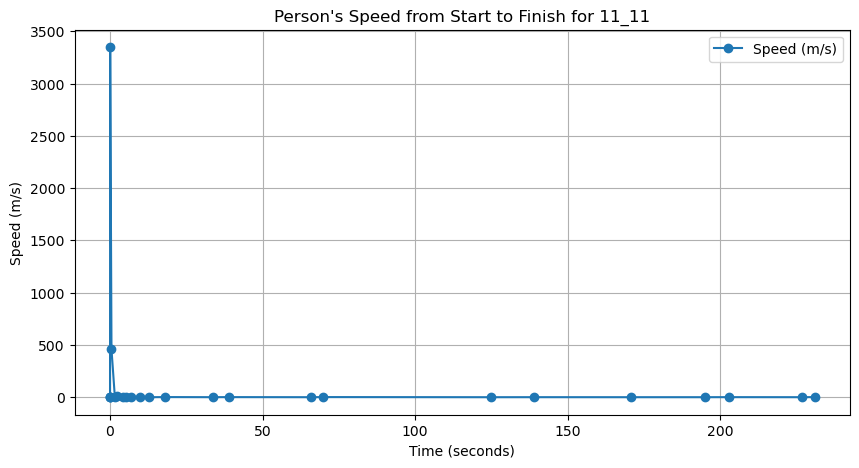

Total distance traveled for 11_9: 178.97 meters


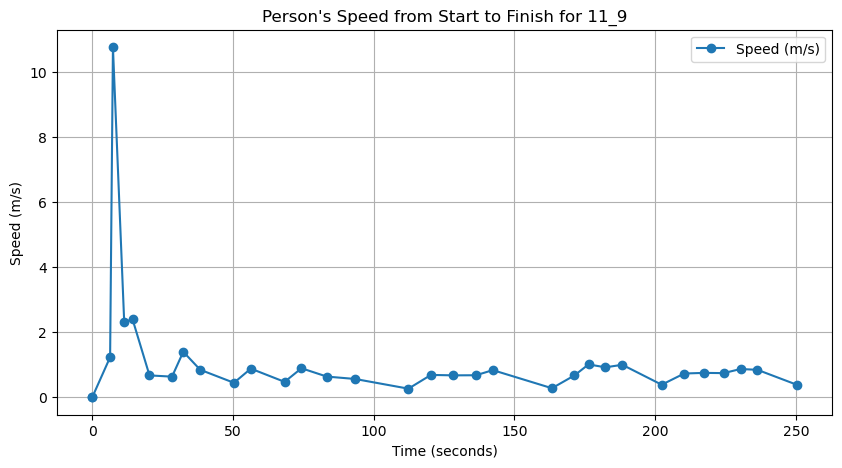

Total distance traveled for 11_7: 320.72 meters


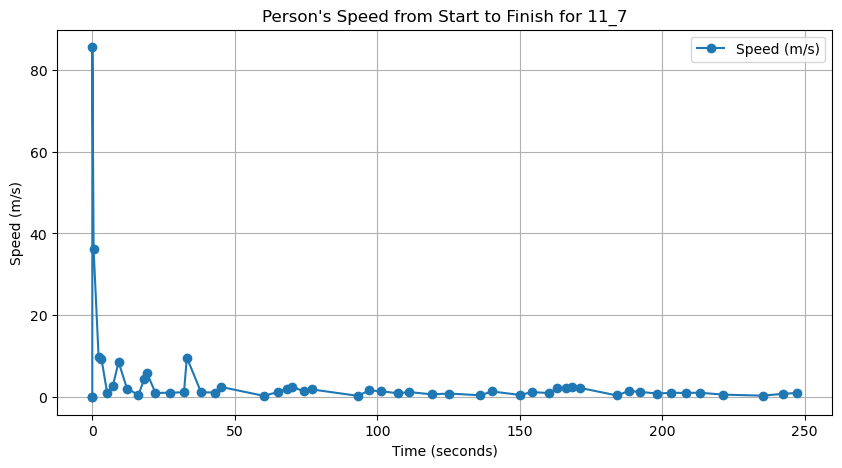

Total distance traveled for 11_0: 570.14 meters


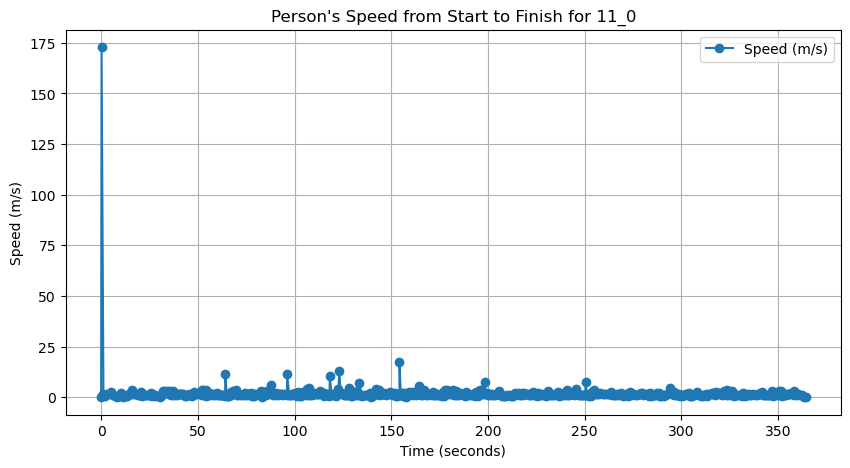

Total distance traveled for 18_2: 488.34 meters


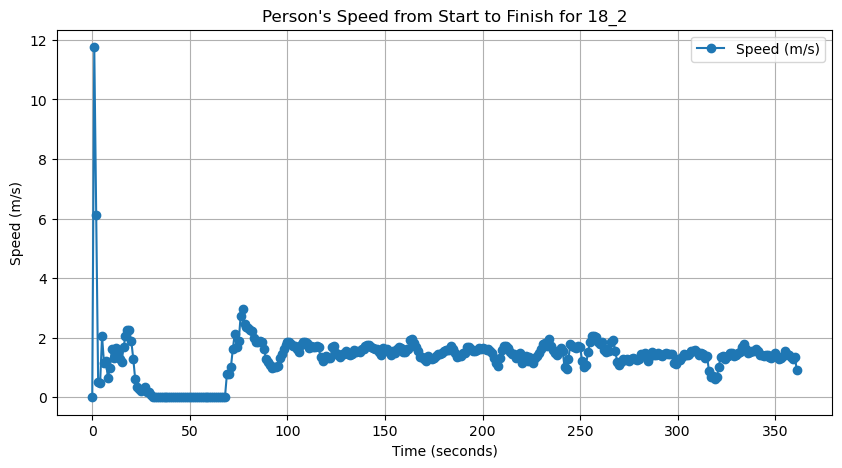

Total distance traveled for 18_3: 519.68 meters


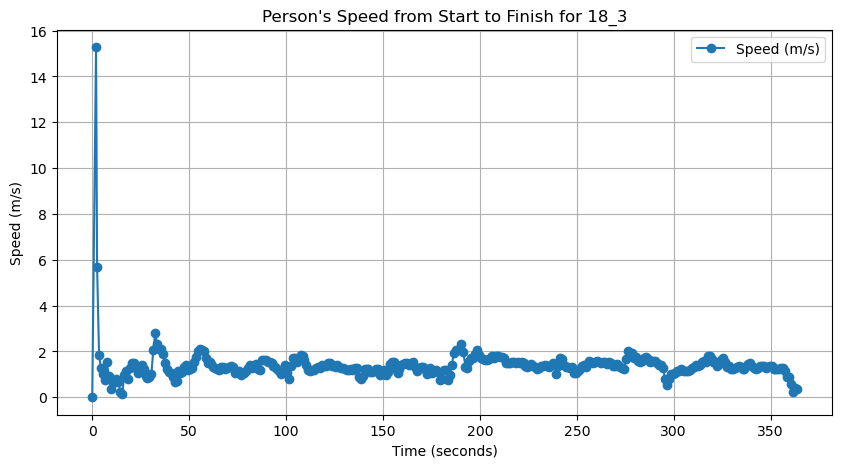

Total distance traveled for 18_4: 529.21 meters


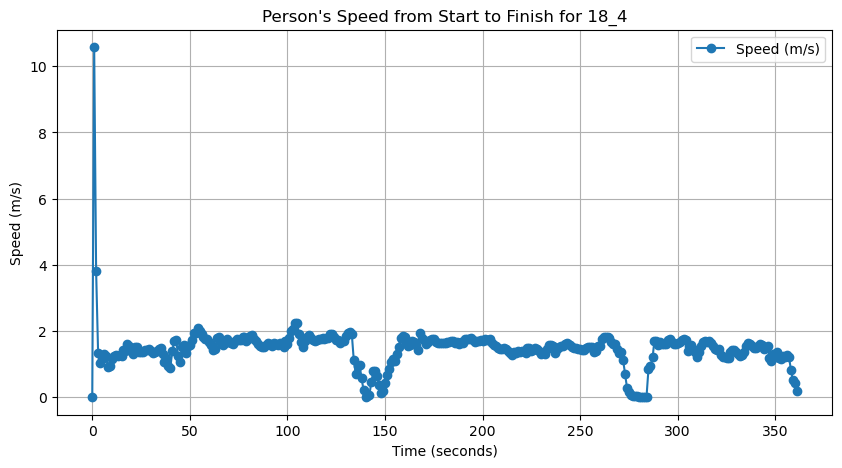

Total distance traveled for 18_1: 428.58 meters


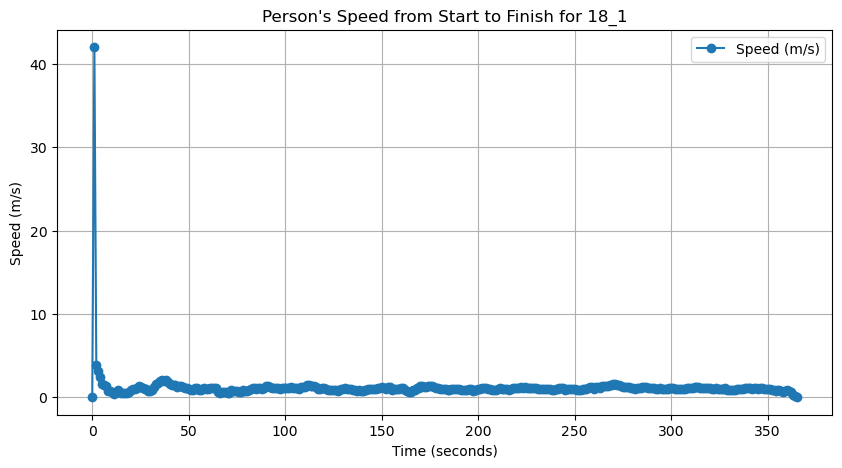

Total distance traveled for 18_0: 382.33 meters


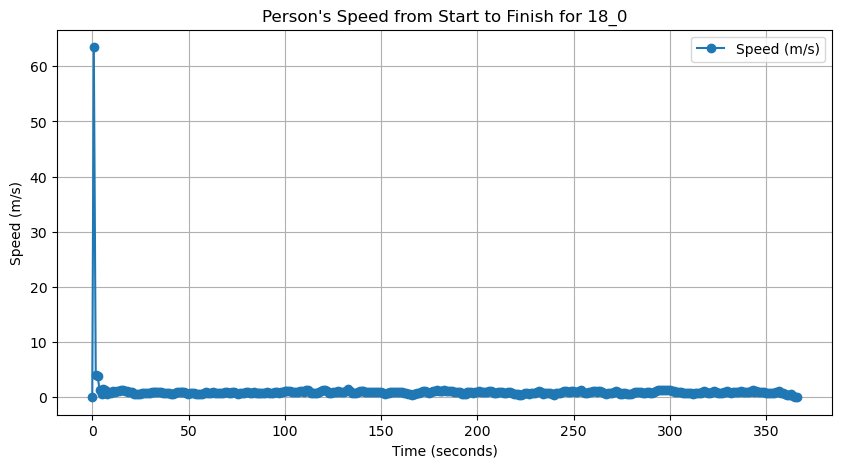

Total distance traveled for 10_8: 260.15 meters


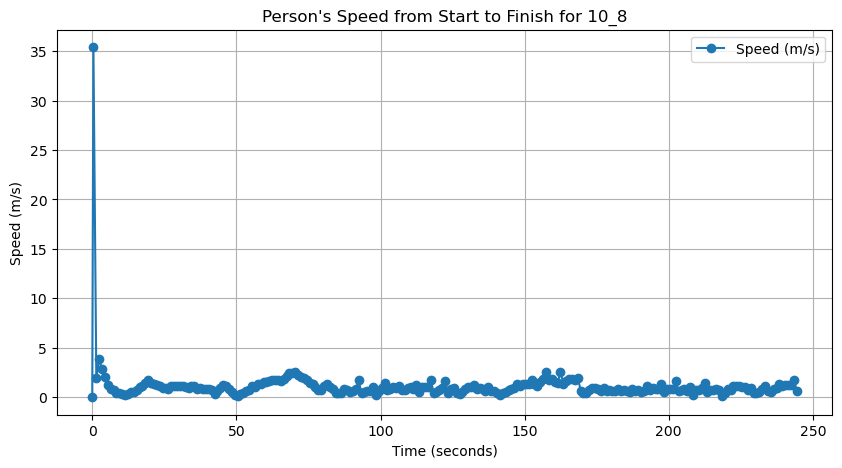

Total distance traveled for 10_6: 633.07 meters


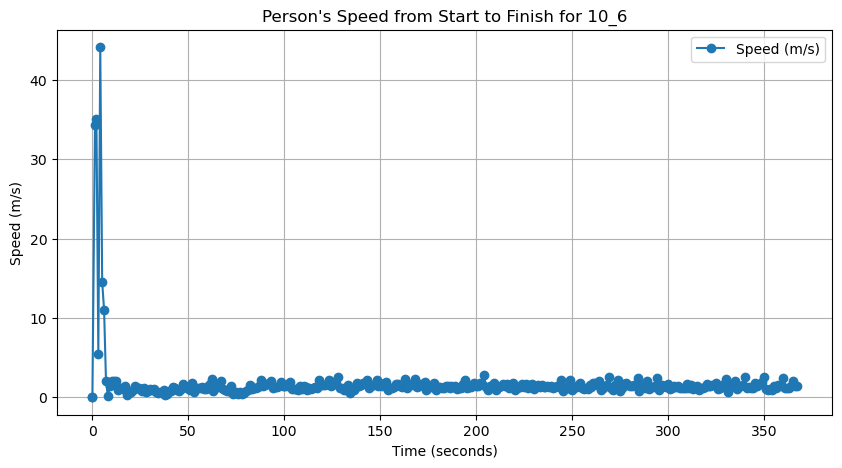

Total distance traveled for 10_1: 438.21 meters


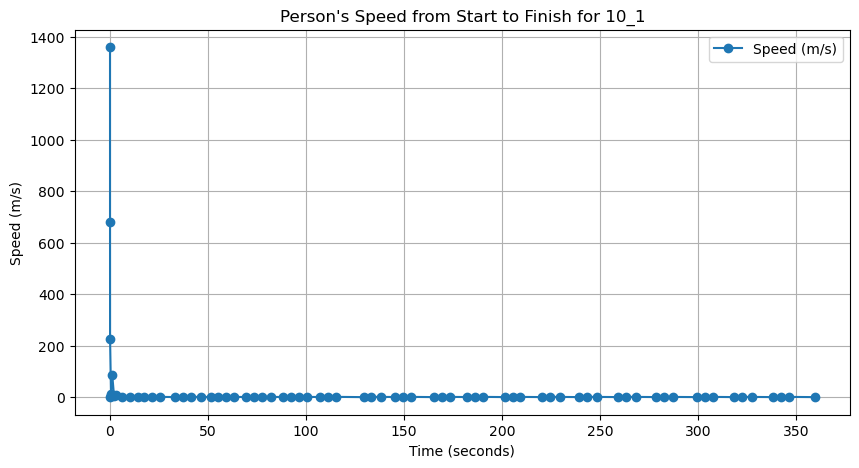

Total distance traveled for 10_0: 443.74 meters


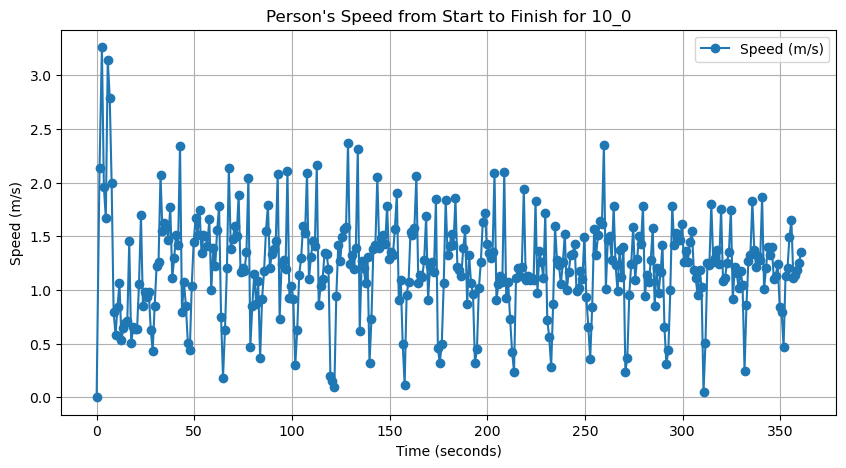

Total distance traveled for 10_7: 568.23 meters


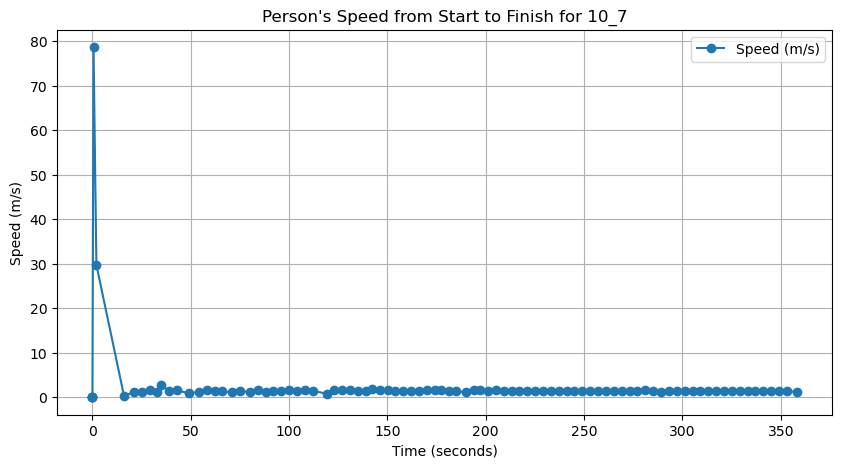

Total distance traveled for 10_9: 368.16 meters


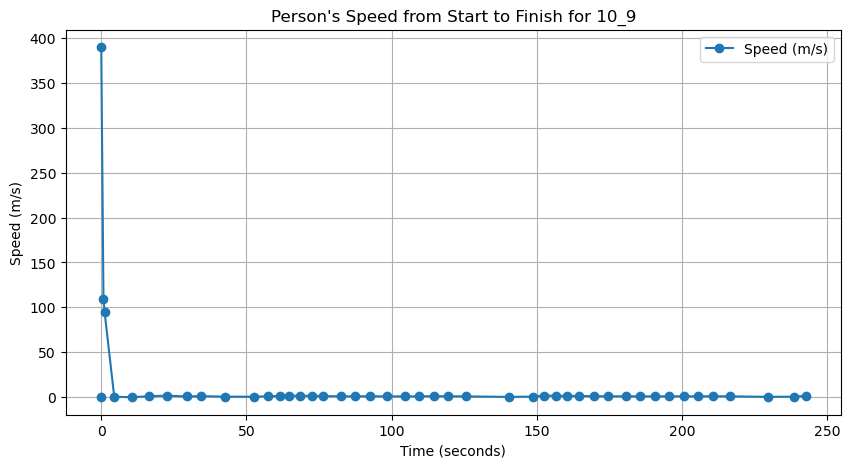

Total distance traveled for 10_15: 450.26 meters


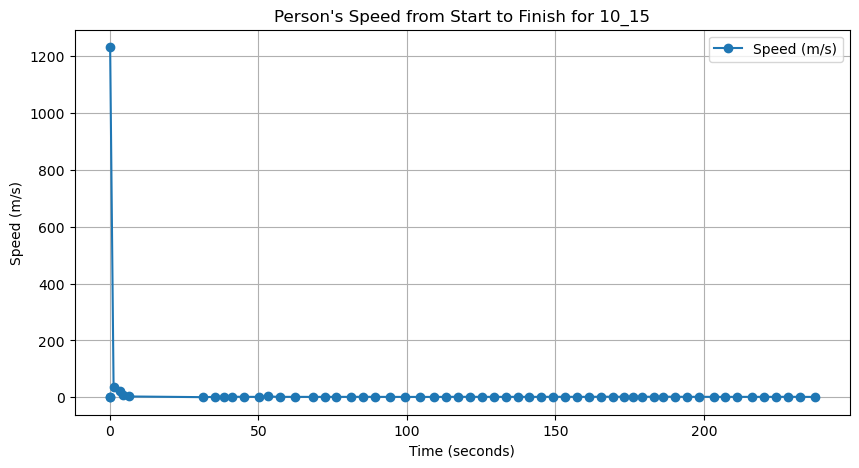

Total distance traveled for 10_12: 279.55 meters


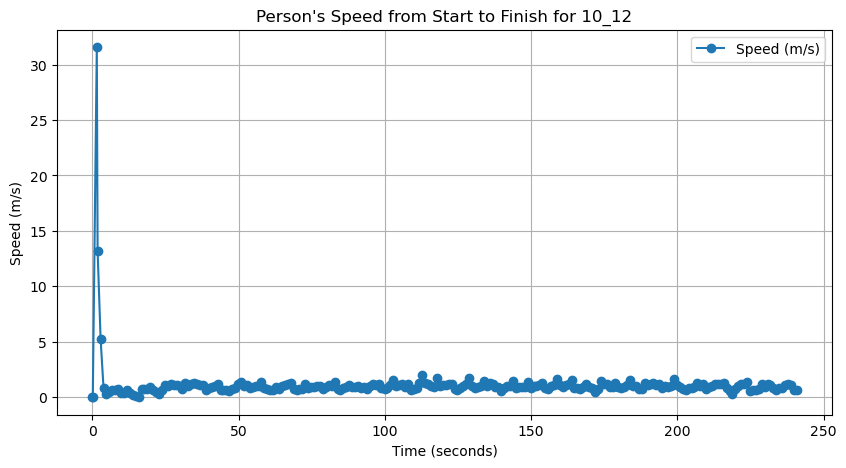

Total distance traveled for 10_13: 1609.47 meters


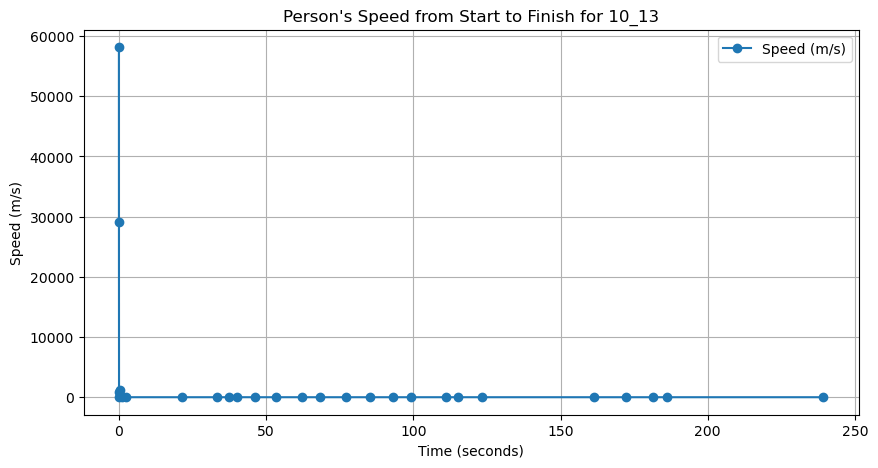

Total distance traveled for 10_14: 365.60 meters


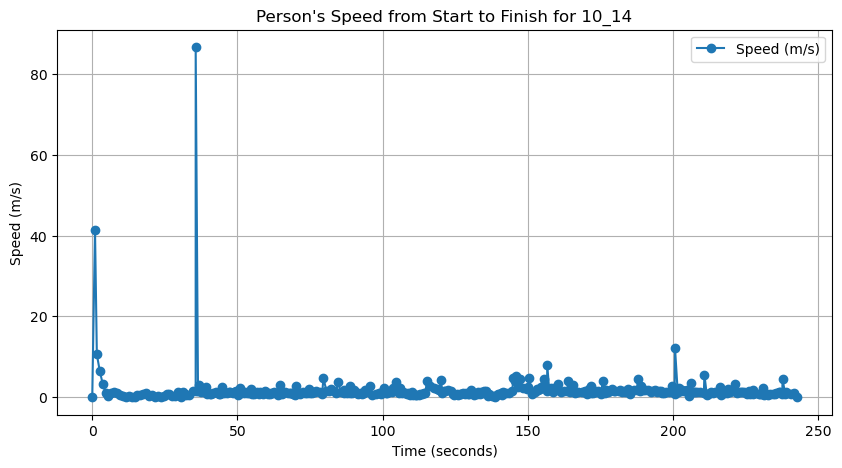

Total distance traveled for 10_2: 547.44 meters


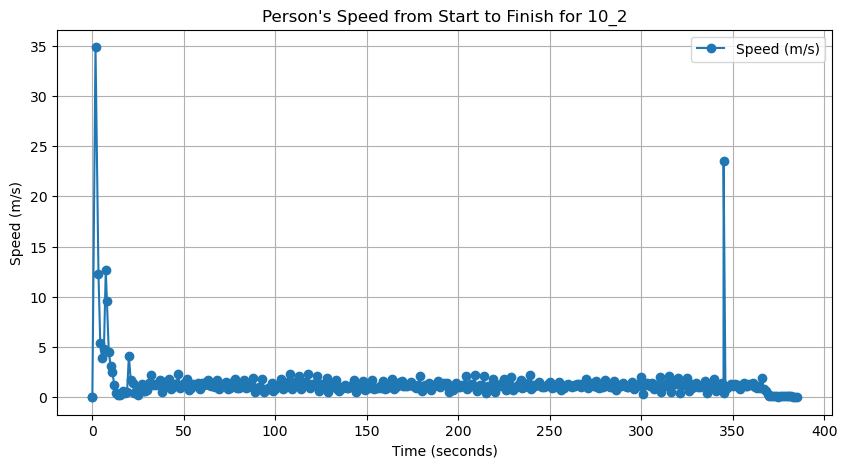

Total distance traveled for 10_5: 514.02 meters


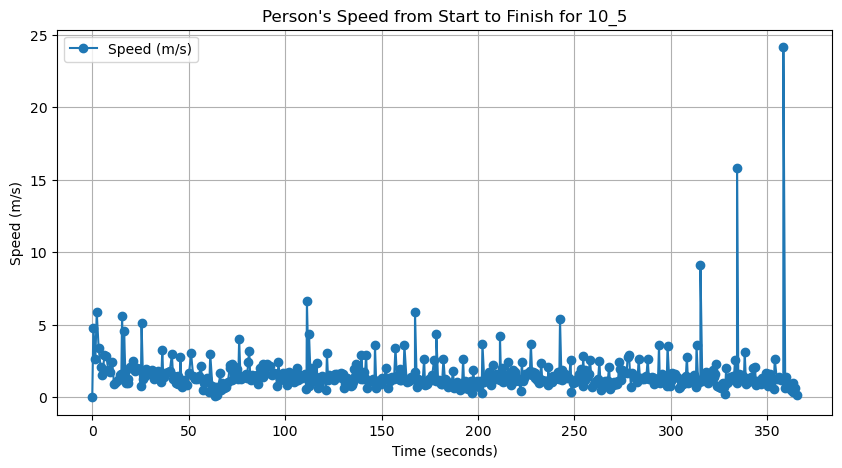

Total distance traveled for 10_4: 468.01 meters


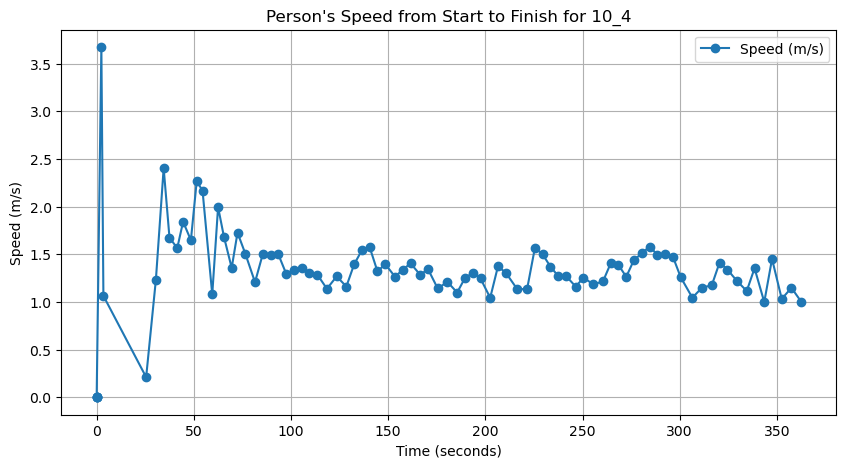

Total distance traveled for 10_3: 882.35 meters


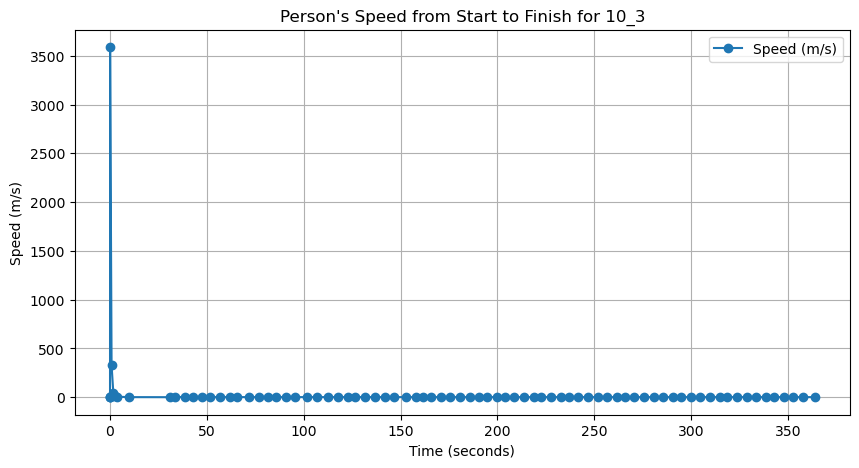

Total distance traveled for 10_11: 217.64 meters


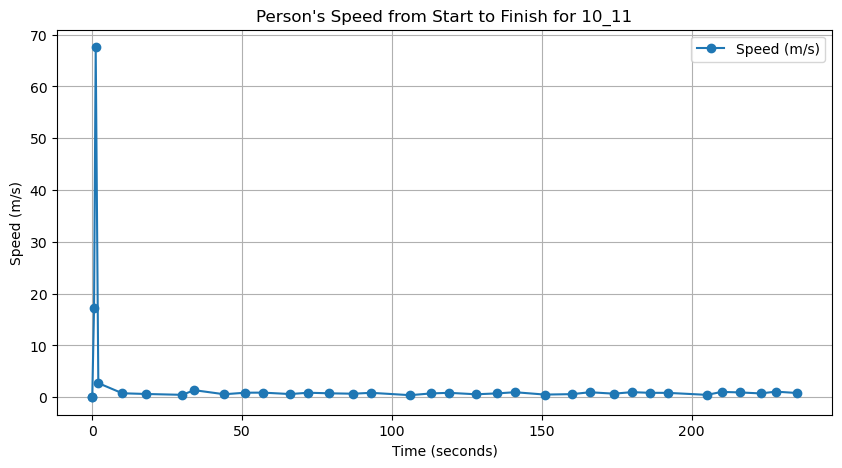

Total distance traveled for 10_16: 176.26 meters


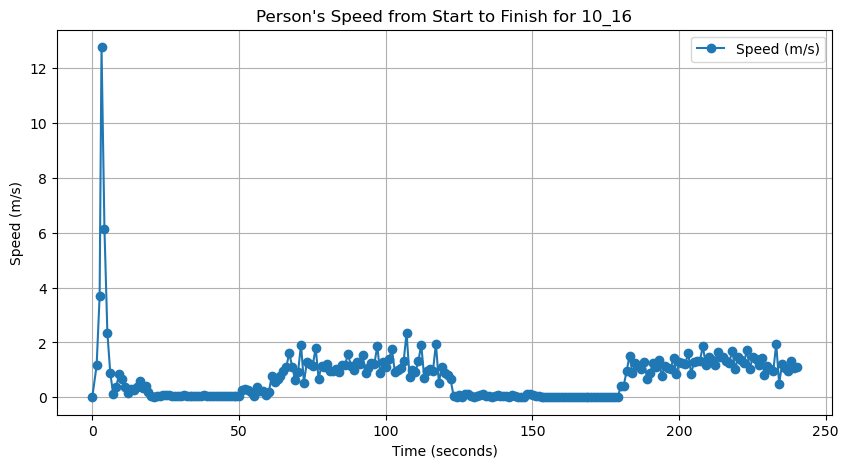

Total distance traveled for 10_17: 322.75 meters


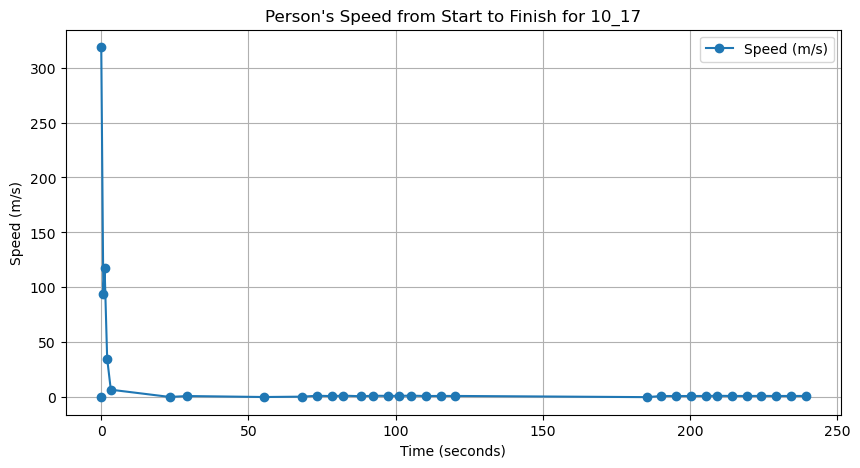

Total distance traveled for 10_10: 183.98 meters


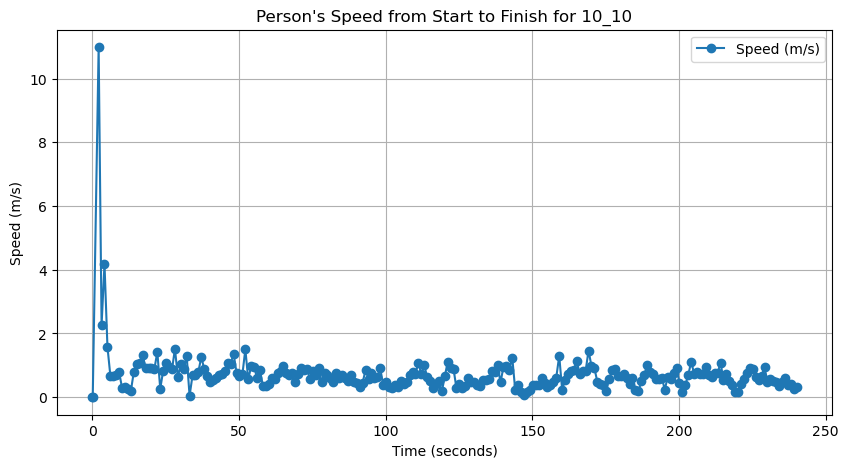

Total distance traveled for 17_0: 675.33 meters


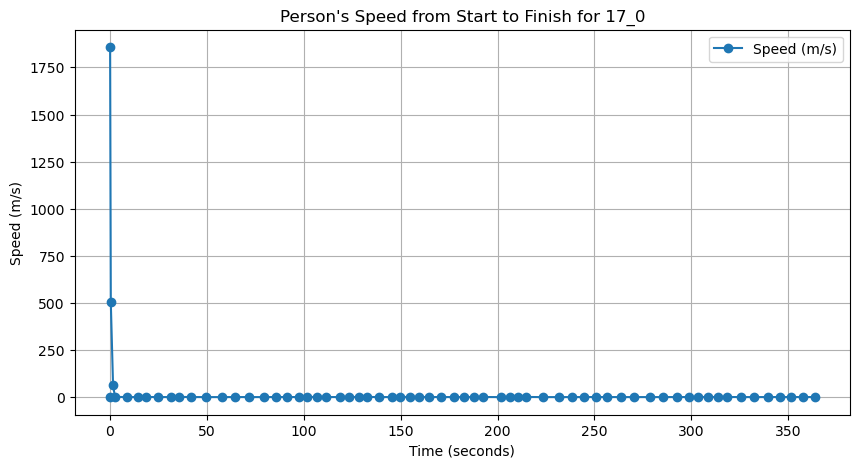

Total distance traveled for 17_1: 485.16 meters


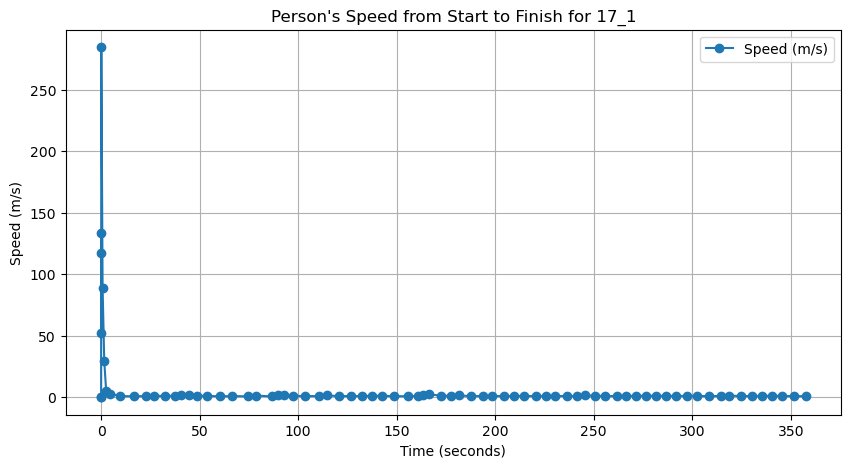

Total distance traveled for 17_4: 557.79 meters


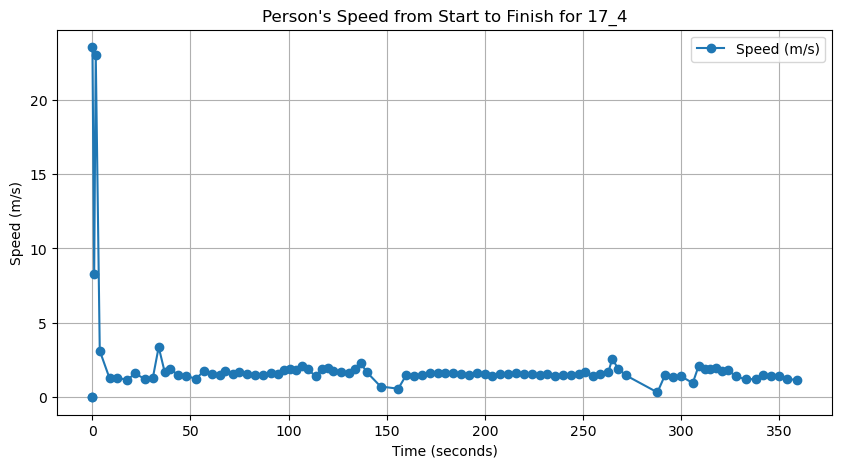

Total distance traveled for 17_3: 632.38 meters


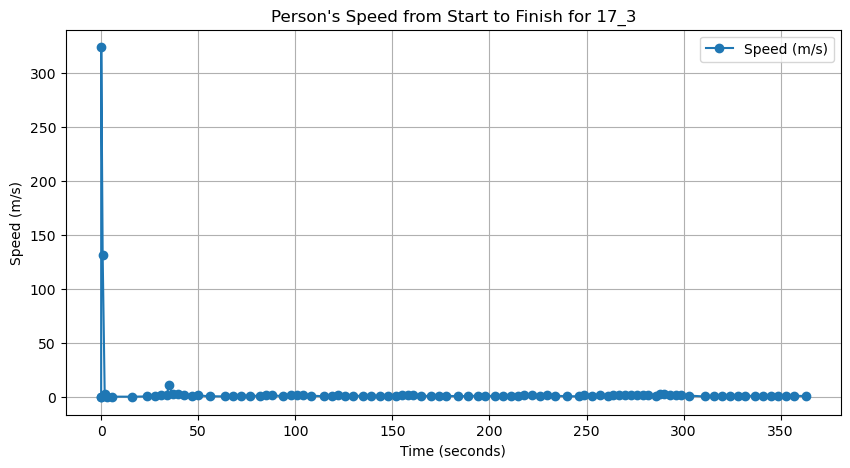

Total distance traveled for 17_2: 581.81 meters


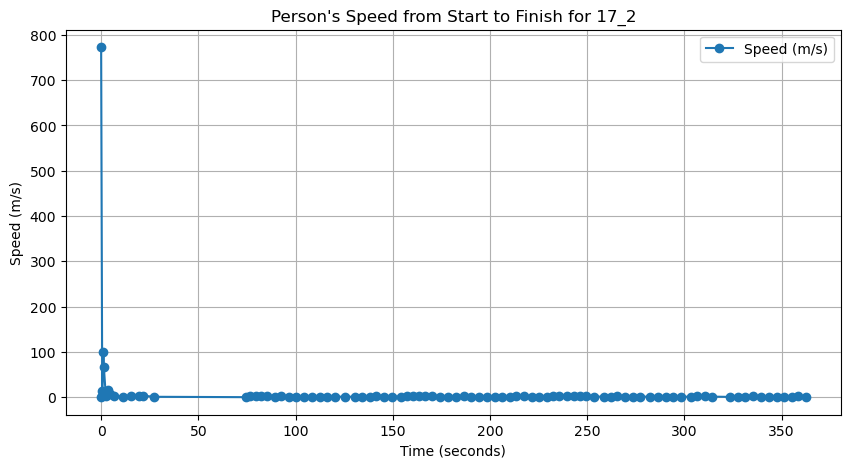

Total distance traveled for 7_2: 702.92 meters


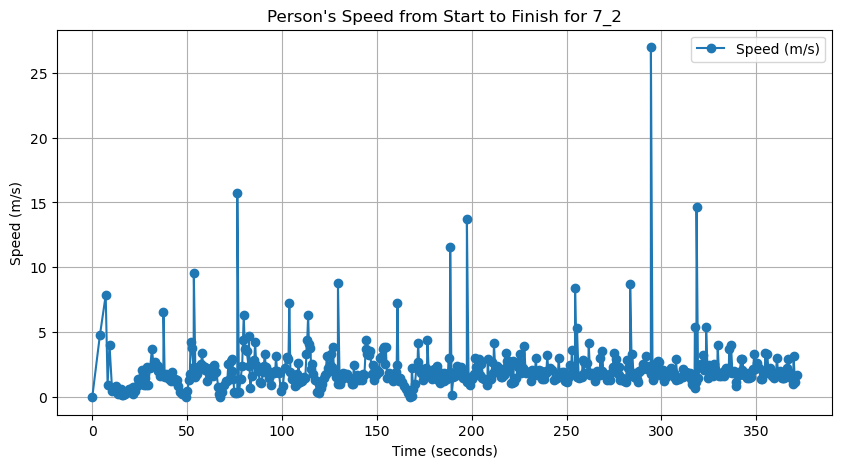

Total distance traveled for 7_5: 1861.12 meters


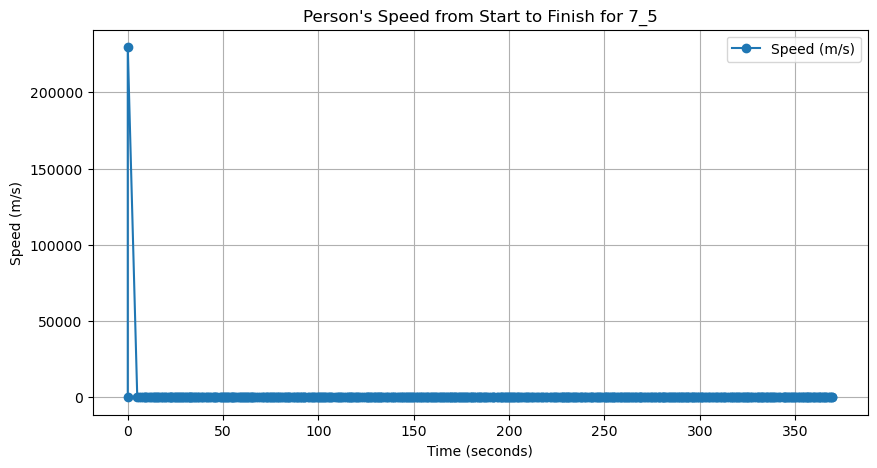

Total distance traveled for 7_4: 642.00 meters


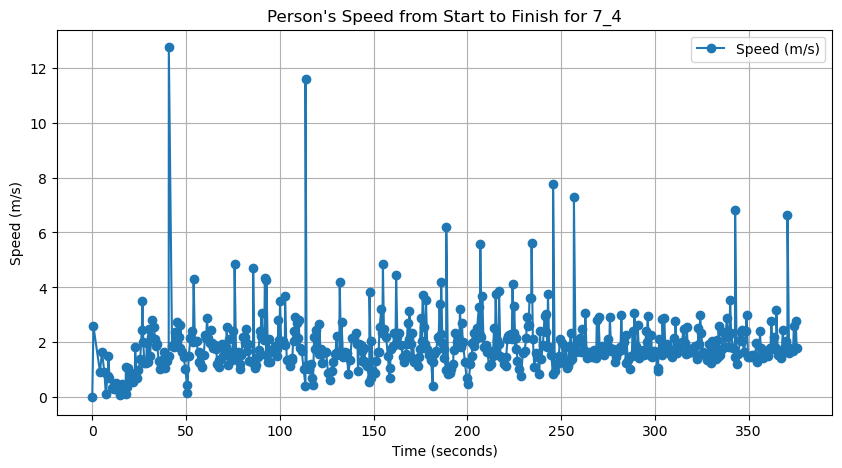

Total distance traveled for 7_3: 663.87 meters


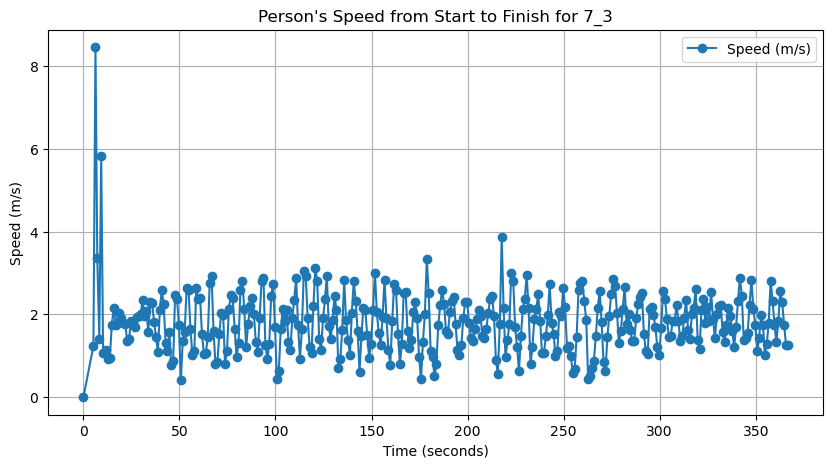

Total distance traveled for 7_6: 948.32 meters


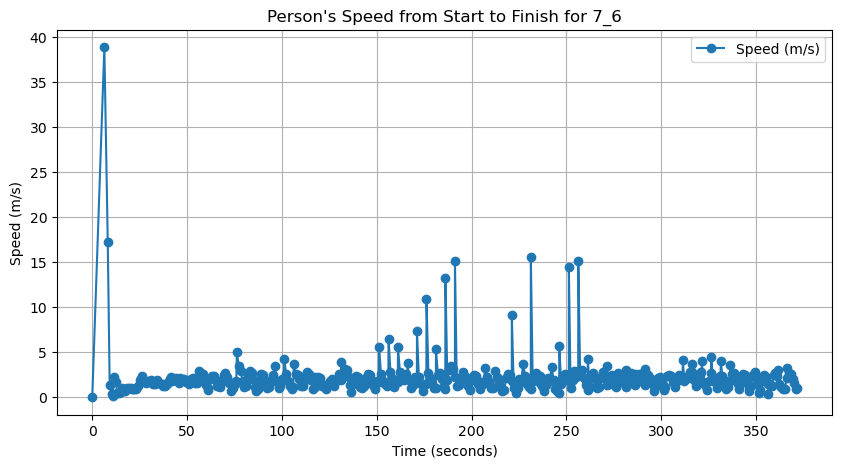

Total distance traveled for 7_1: 669.71 meters


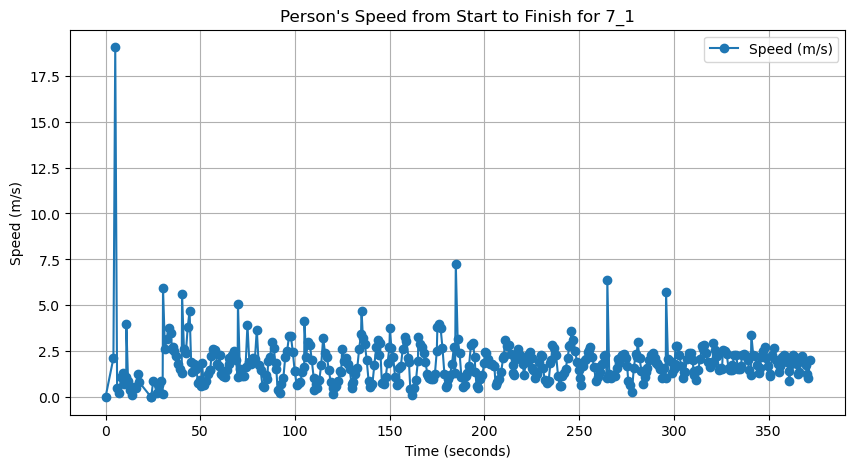

Total distance traveled for 7_8: 1340.35 meters


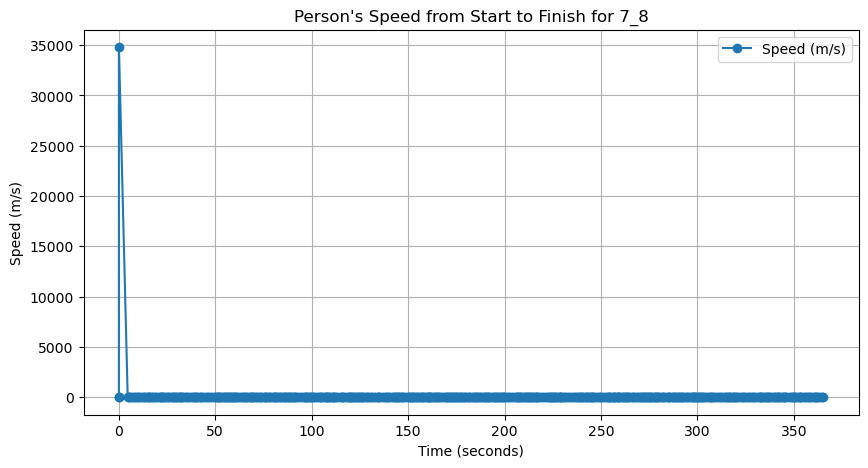

Total distance traveled for 7_9: 970.56 meters


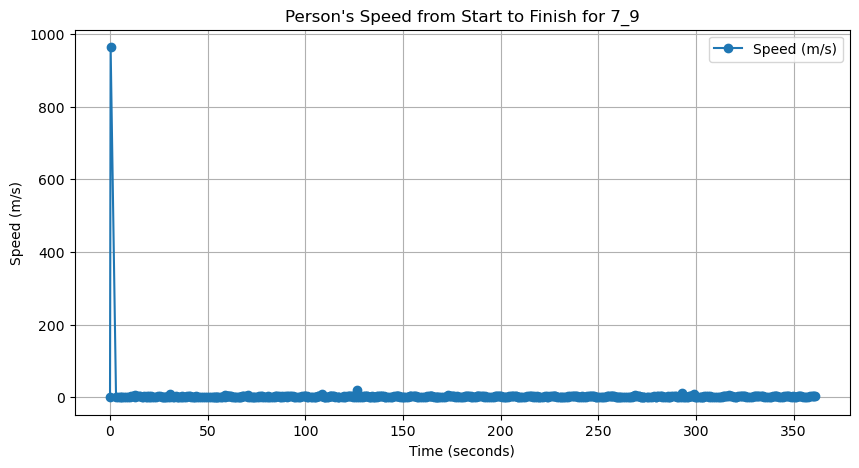

Total distance traveled for 7_0: 1136.44 meters


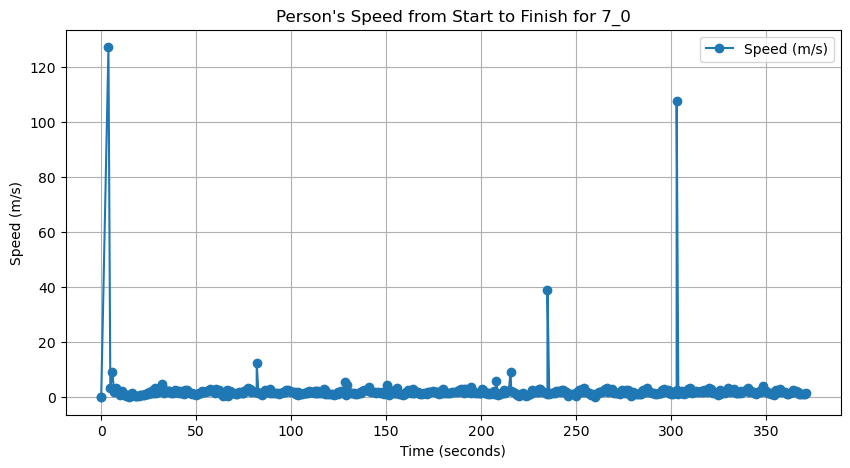

Total distance traveled for 7_7: 696.52 meters


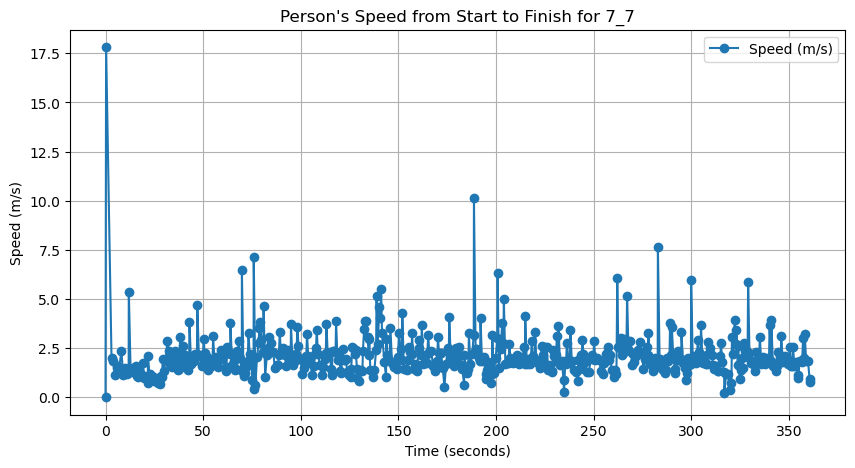

Total distance traveled for 8_7: 437.15 meters


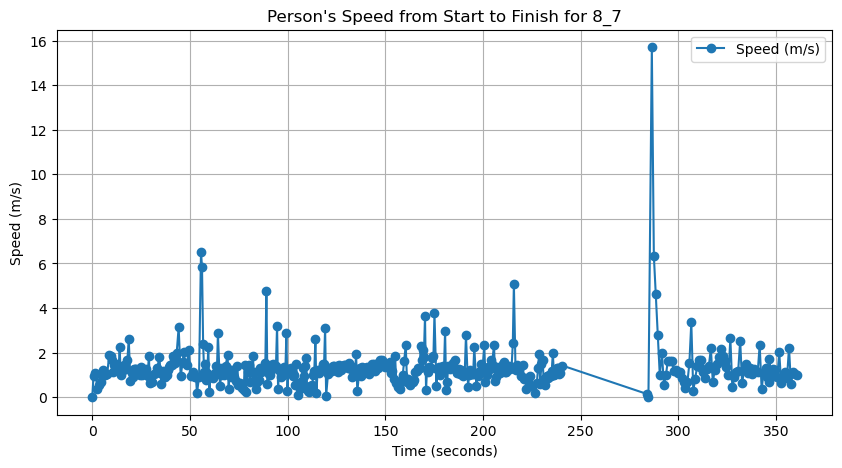

Total distance traveled for 8_0: 542.65 meters


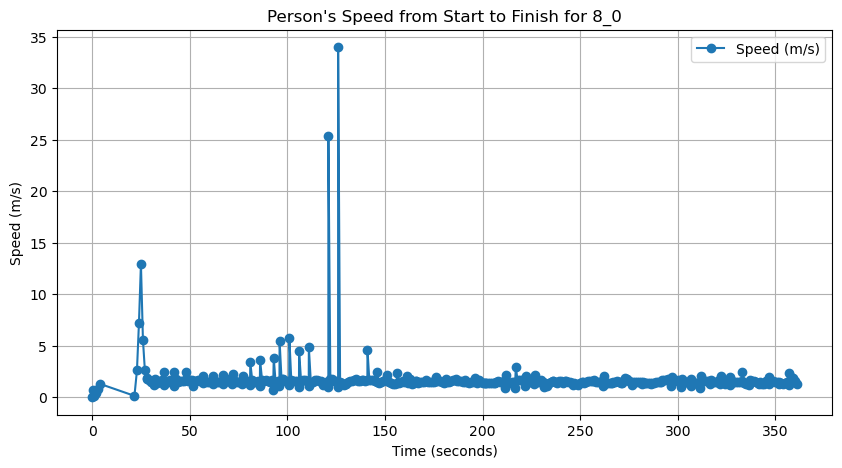

Total distance traveled for 8_9: 1002.30 meters


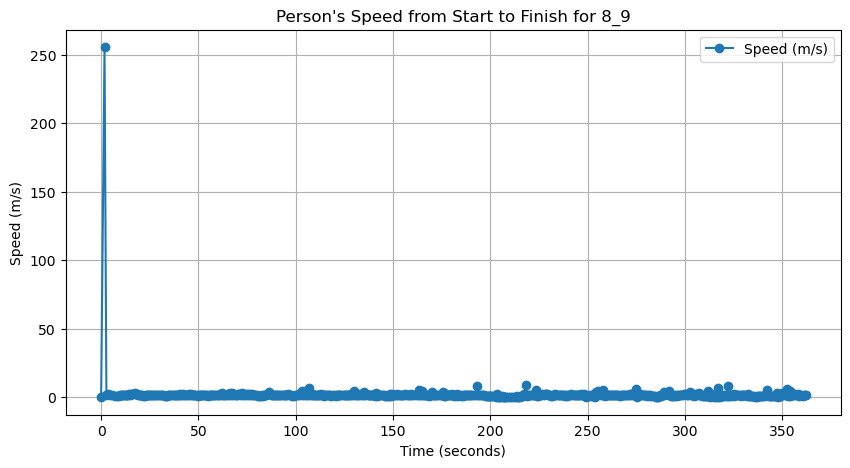

Total distance traveled for 8_8: 547.87 meters


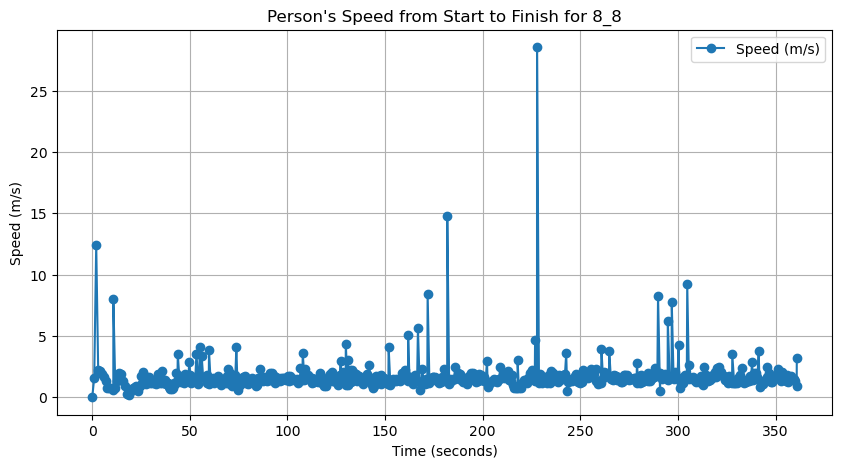

Total distance traveled for 8_1: 568.85 meters


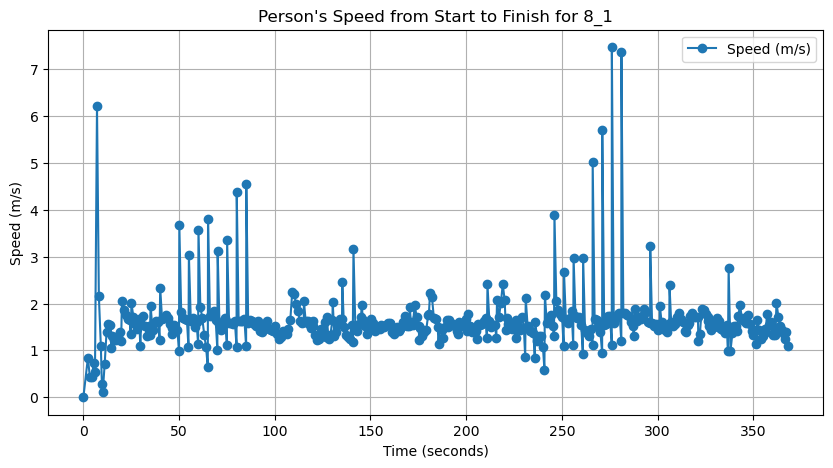

Total distance traveled for 8_6: 554.82 meters


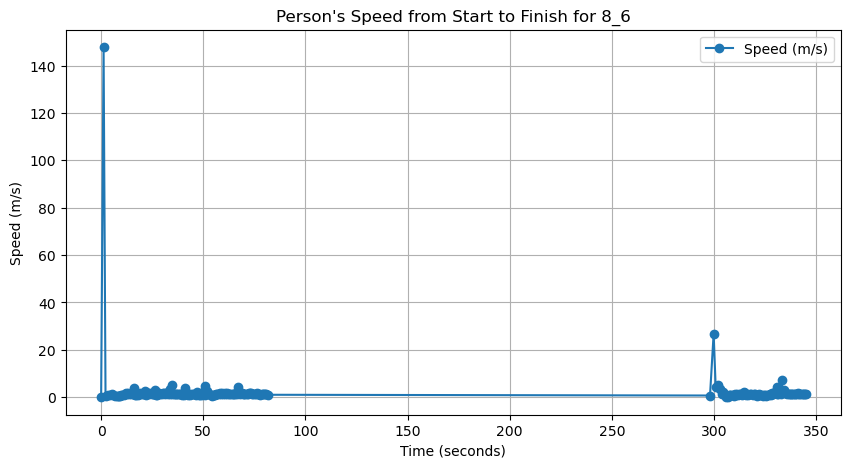

Total distance traveled for 8_3: 606.90 meters


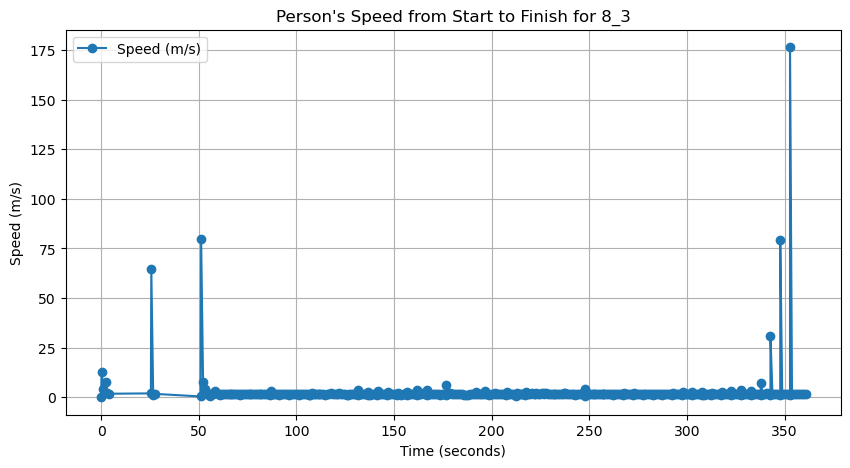

Total distance traveled for 8_4: 670.09 meters


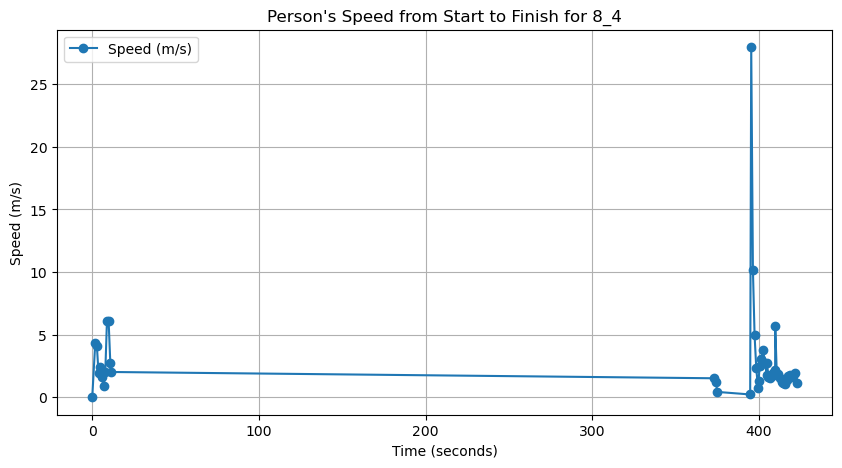

Total distance traveled for 8_10: 9811.05 meters


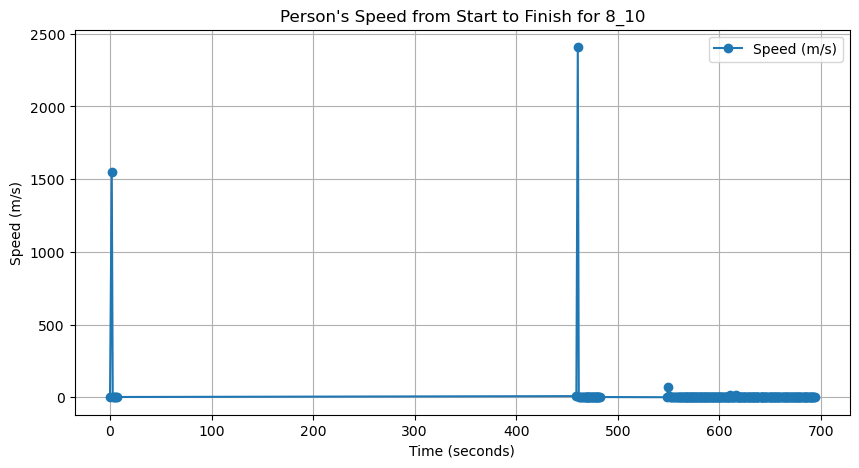

Total distance traveled for 8_5: 578.26 meters


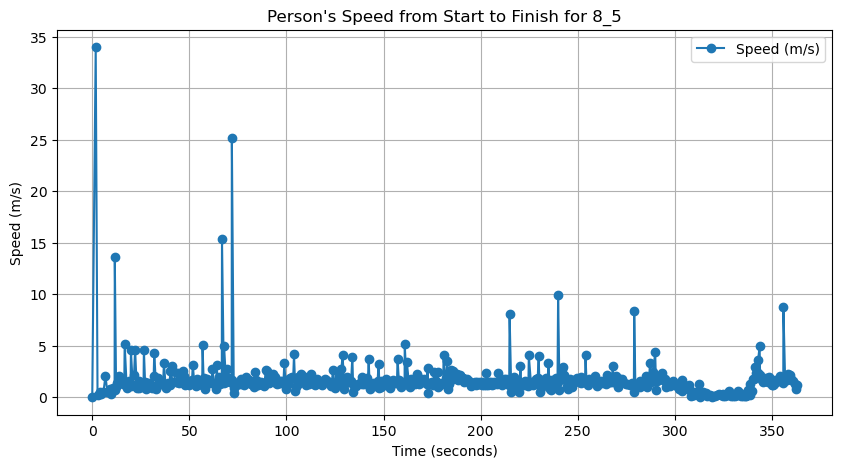

Total distance traveled for 8_2: 957.54 meters


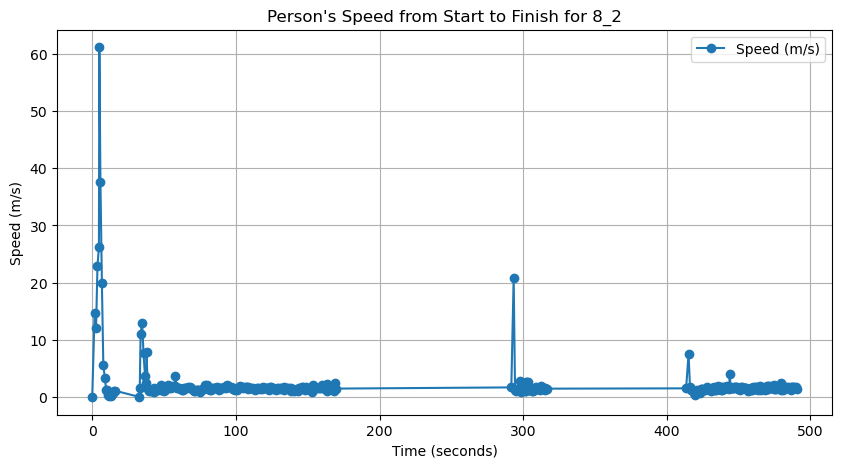

Total distance traveled for 6_8: 595.23 meters


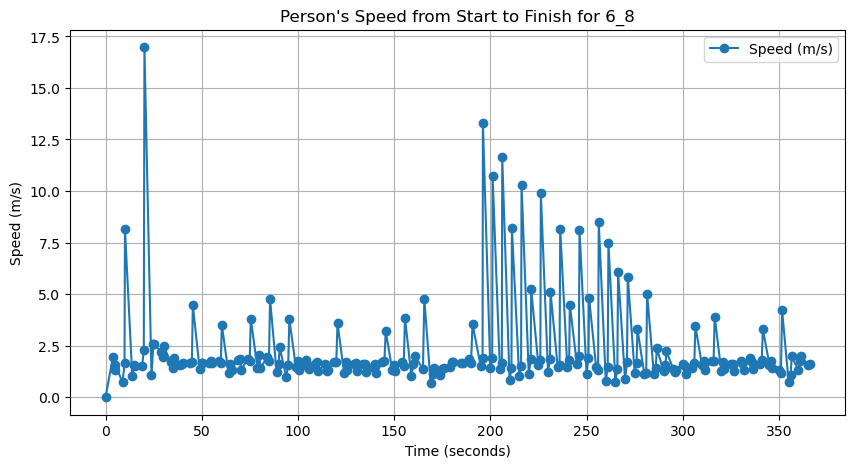

Total distance traveled for 6_1: 540.01 meters


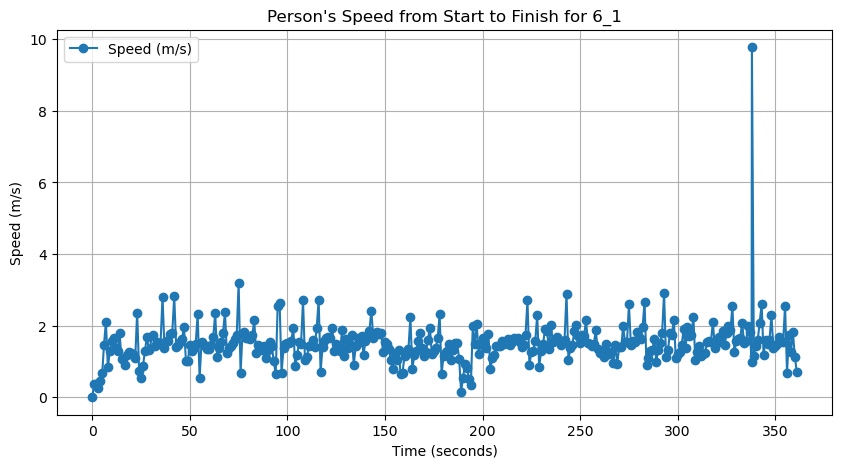

Total distance traveled for 6_6: 476.23 meters


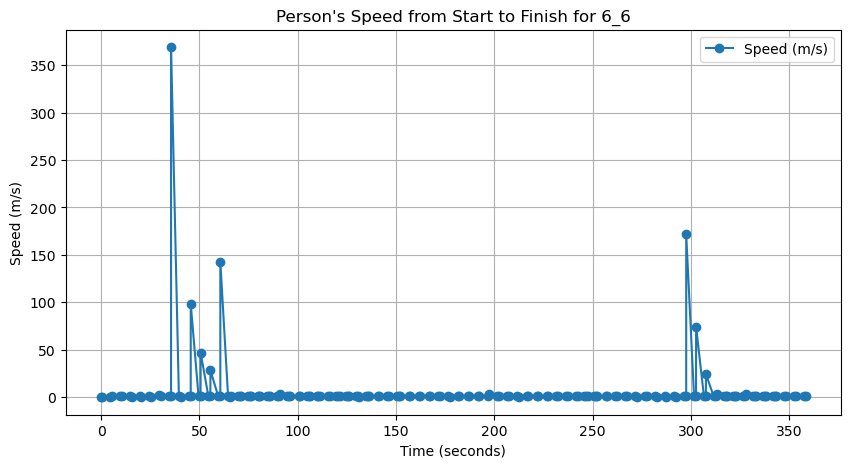

Total distance traveled for 6_7: 566.31 meters


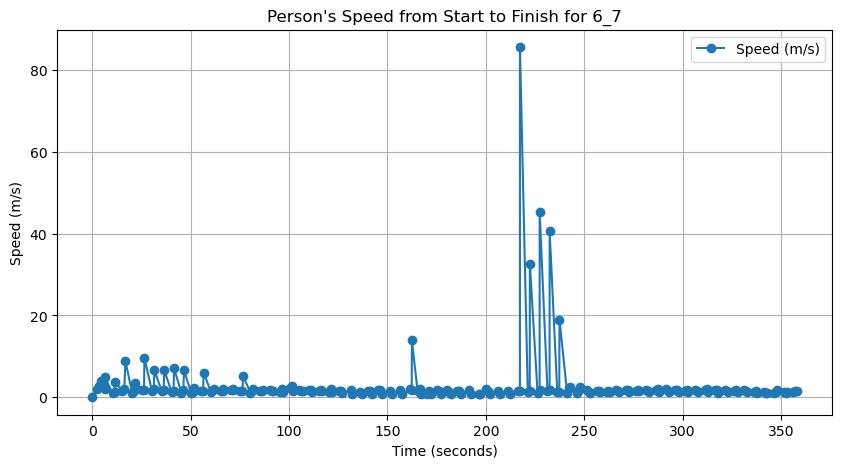

Total distance traveled for 6_0: 518.58 meters


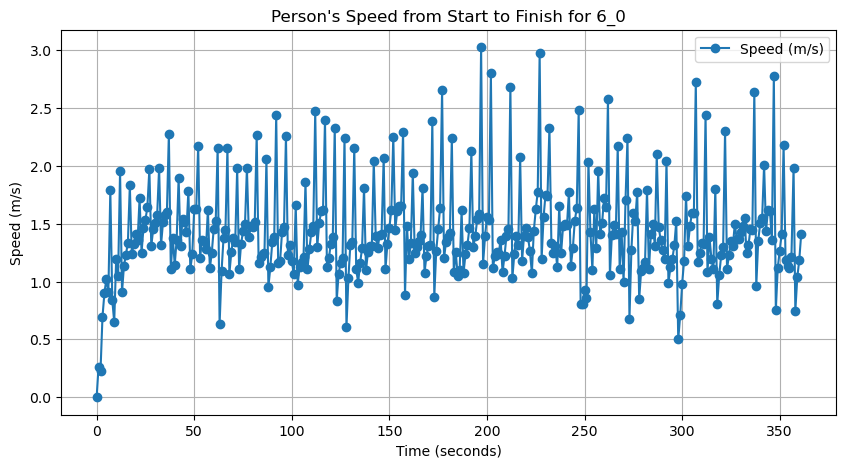

Total distance traveled for 6_9: 610.22 meters


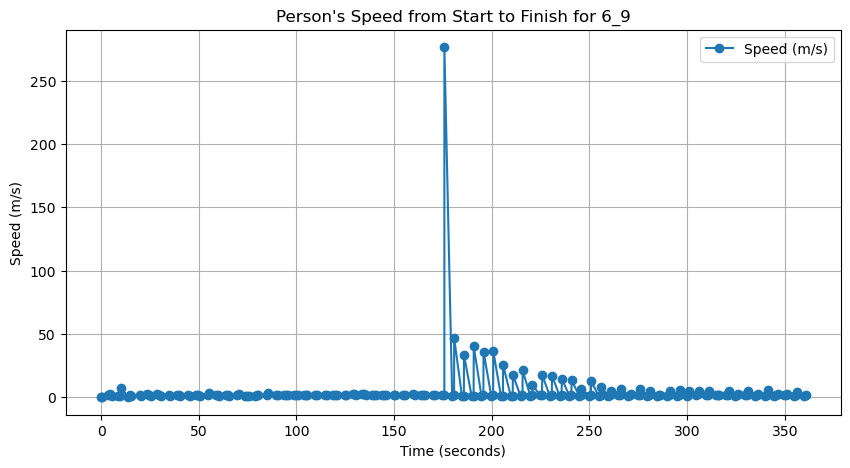

Total distance traveled for 6_5: 469.90 meters


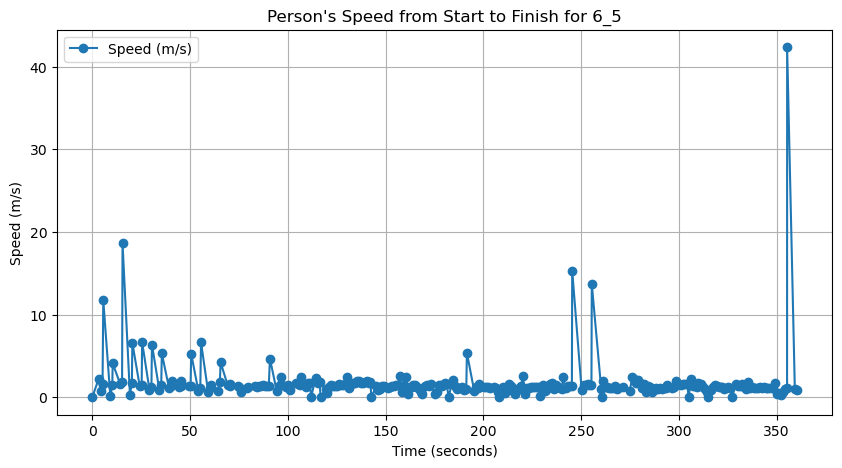

Total distance traveled for 6_2: 613.62 meters


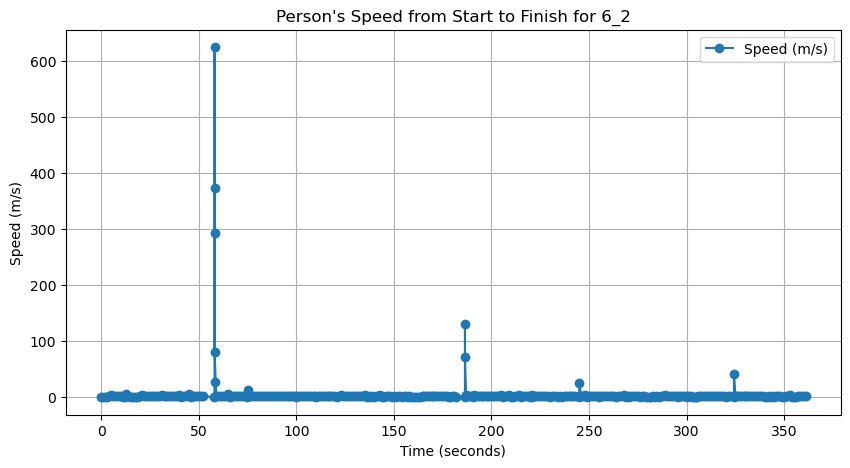

Total distance traveled for 6_3: 564.84 meters


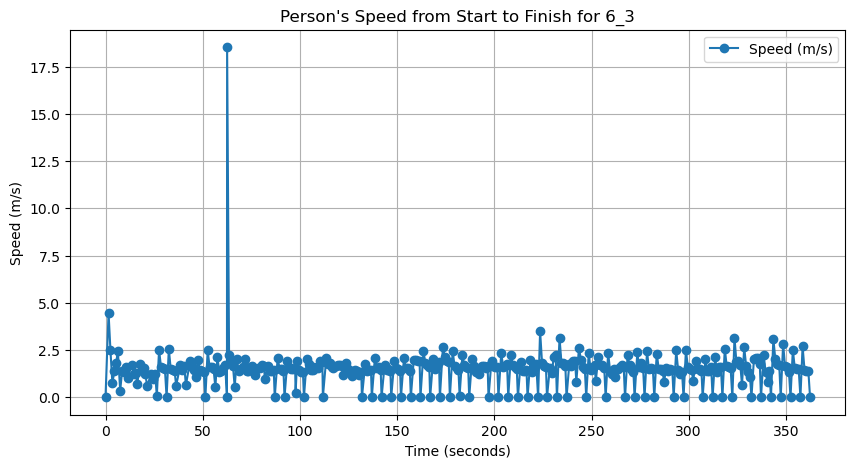

Total distance traveled for 6_4: 722.21 meters


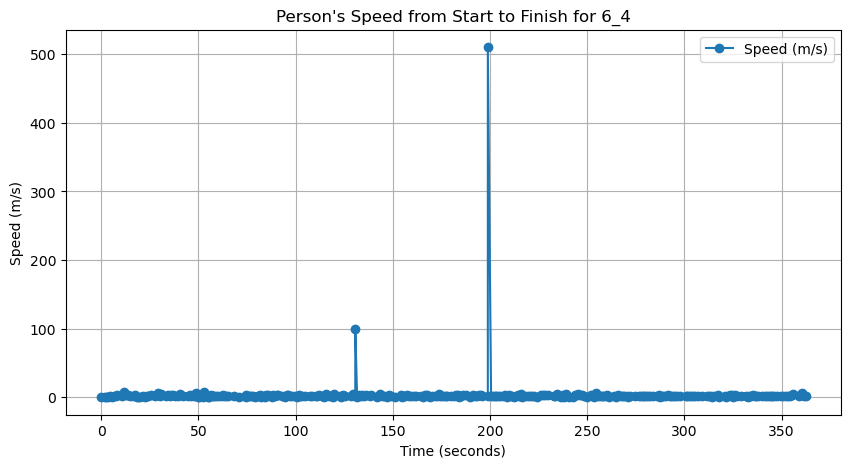

Total distance traveled: 722.21 meters


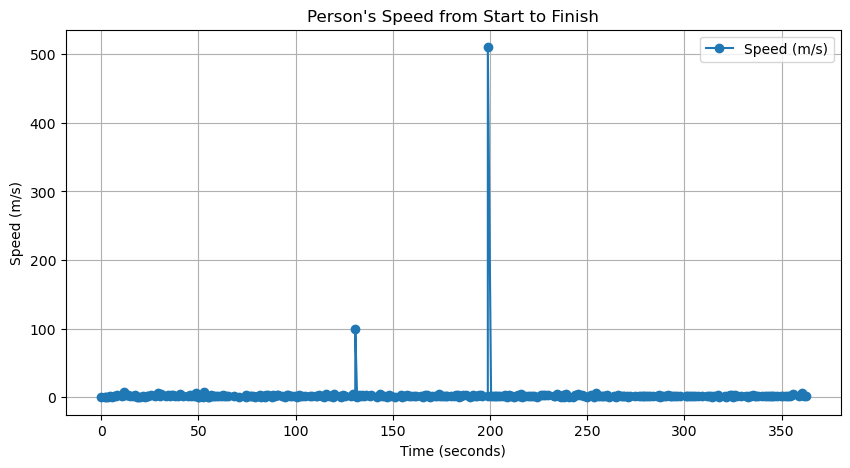

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def haversine(lat1, lon1, lat2, lon2):
    """Calculates the distance between two latitude/longitude points in meters."""
    R = 6371000  # Earth's radius in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

for test in selection:
    positions_data = test.positions

    # Convert time to seconds from start
    positions_data['time_s'] = (positions_data['ms'] - positions_data['ms'].min()) / 1000

    # Calculate distance between points
    positions_data['distance_m'] = [0] + [
        haversine(positions_data['latitude'][i-1], positions_data['longitude'][i-1],
                  positions_data['latitude'][i], positions_data['longitude'][i])
        for i in range(1, len(positions_data))
    ]

    # Calculate total distance traveled
    total_distance = positions_data['distance_m'].sum()
    print(f"Total distance traveled for {test.filename}: {total_distance:.2f} meters")

    # Calculate speed (m/s)
    positions_data['speed_mps'] = positions_data['distance_m'] / positions_data['time_s'].diff().fillna(1)

    # Create speed plot
    plt.figure(figsize=(10, 5))
    plt.plot(positions_data['time_s'], positions_data['speed_mps'], marker='o', linestyle='-', label='Speed (m/s)')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Speed (m/s)')
    plt.title(f"Person's Speed from Start to Finish for {test.filename}")
    plt.legend()
    plt.grid()
    plt.show()

# Convert time to seconds from start
positions_data['time_s'] = (positions_data['ms'] - positions_data['ms'].min()) / 1000

# Calculate distance between points
positions_data['distance_m'] = [0] + [
    haversine(positions_data['latitude'][i-1], positions_data['longitude'][i-1],
              positions_data['latitude'][i], positions_data['longitude'][i])
    for i in range(1, len(positions_data))
]

# Calculate total distance traveled
total_distance = positions_data['distance_m'].sum()
print(f"Total distance traveled: {total_distance:.2f} meters")

# Calculate speed (m/s)
positions_data['speed_mps'] = positions_data['distance_m'] / positions_data['time_s'].diff().fillna(1)

# Create speed plot
plt.figure(figsize=(10, 5))
plt.plot(positions_data['time_s'], positions_data['speed_mps'], marker='o', linestyle='-', label='Speed (m/s)')
plt.xlabel('Time (seconds)')
plt.ylabel('Speed (m/s)')
plt.title("Person's Speed from Start to Finish")
plt.legend()
plt.grid()
plt.show()


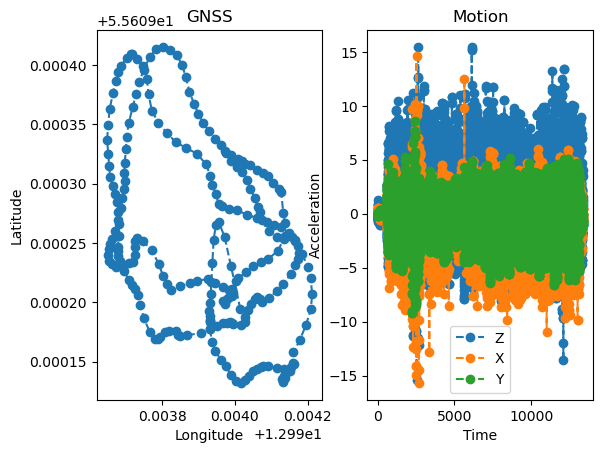

In [18]:
# Example of how to plot position data
fig = plt.figure()
ax = fig.add_subplot(121)
ax.plot(selection[0].positions['longitude'], selection[0].positions['latitude'],'o--')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('GNSS')

ax = fig.add_subplot(122)
ax.plot(selection[0].motion['accelZ'],'o--', label='Z')
ax.plot(selection[0].motion['accelX'],'o--', label='X')
ax.plot(selection[0].motion['accelY'],'o--', label='Y')
ax.set_xlabel('Time')
ax.set_ylabel('Acceleration')
ax.legend()
ax.set_title('Motion')
plt.show()


In [19]:
metadata.head()

,subject,testID,testName,isPatient,distanceReference,hasMotion,hasGNSS,device,distanceByApp,totSteps,...,gt_type,country,gnss_anonimized,duration [s],fs_acc,fs_gnss,fs_steps,average_walking_speed,smartphone_position,smartphone app
0,0,0,0_0,True,623,False,True,"Apple iPhone11,8",598.373421,755.0,...,final,UK,True,368,NaN,0.304348,0.380435,1.692935,hand held,Timed Walk
1,0,1,0_1,True,598,False,True,"Apple iPhone11,8",587.334804,699.0,...,final,UK,True,380,NaN,0.292105,0.357895,1.573684,hand held,Timed Walk
2,0,2,0_2,True,584,False,True,"Apple iPhone11,8",577.005522,726.0,...,final,UK,True,359,NaN,0.281337,0.381616,1.626741,hand held,Timed Walk
3,0,3,0_3,True,577,False,True,"Apple iPhone11,8",539.365038,710.0,...,final,UK,True,365,NaN,0.284932,0.372603,1.580822,hand held,Timed Walk
4,0,4,0_4,True,590,False,True,"Apple iPhone11,8",566.744323,715.0,...,final,UK,True,360,NaN,0.277778,0.375000,1.638889,hand held,Timed Walk


In [20]:
metadata['smartphone_position'].value_counts()

smartphone_position
hand held    203
Name: count, dtype: int64